In [7]:
import sys
"/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis/rmg_gua/plotting" in sys.path

True

In [3]:
import copy
import pickle
import shutil
import os
import math
import yaml
import pandas as pd
import time
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms

import numpy as np
import scipy.stats as stats
import sys
repo_dir = '/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis'
if repo_dir not in sys.path:
    sys.path.append(repo_dir)

from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
import PEUQSE
import cantera as ct

cantera version:  2.6


In [4]:
!ls /work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/

peuqse_methanol_07Aug  peuqse_methanol_19jul   peuqse_methanol_search_22Jul
peuqse_methanol_10Aug  peuqse_methanol_31_jul  run_all.sh


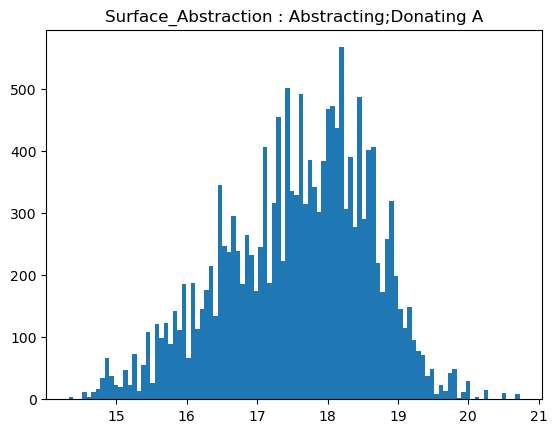

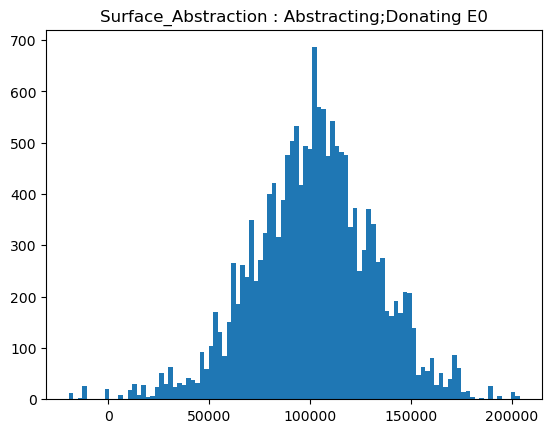

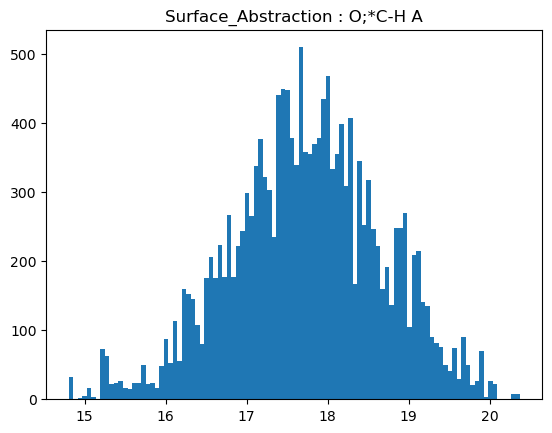

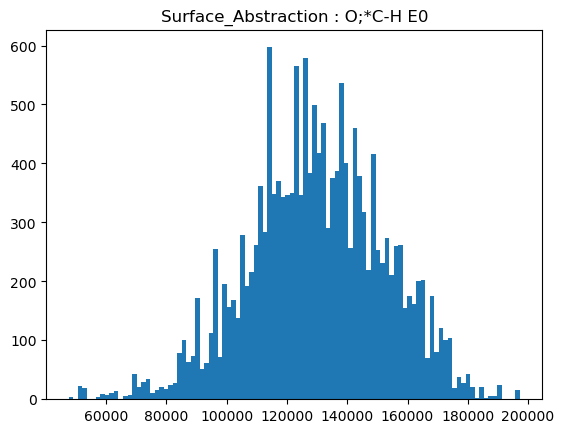

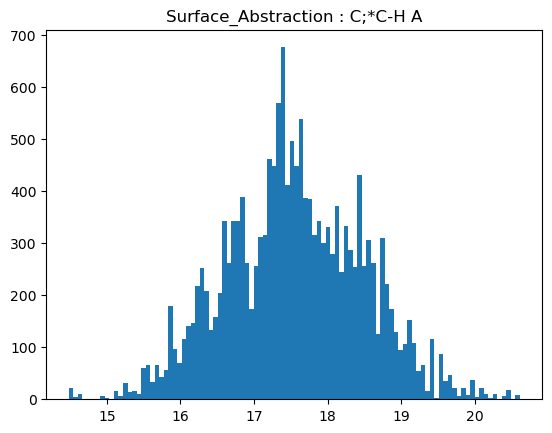

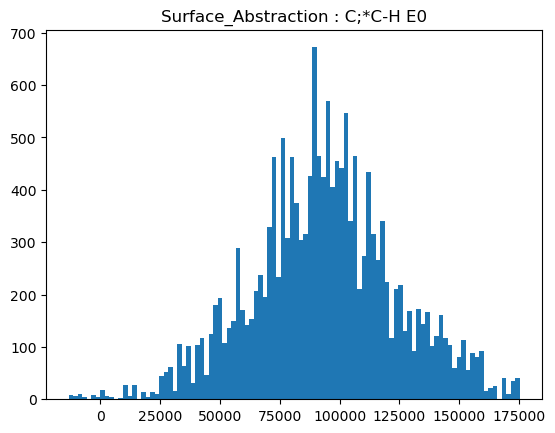

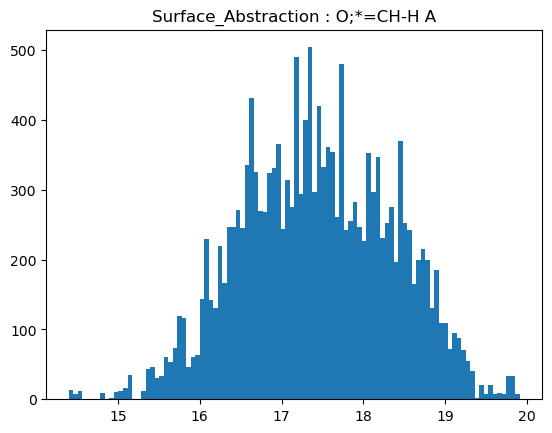

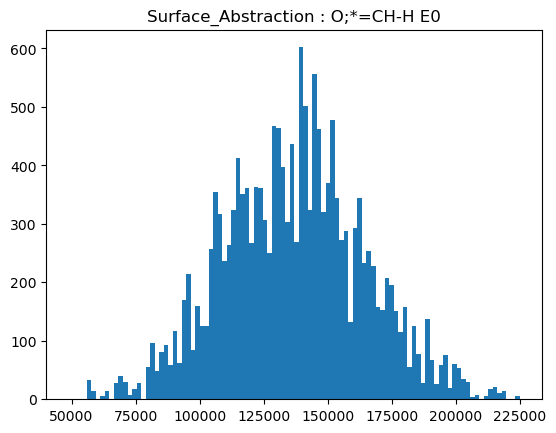

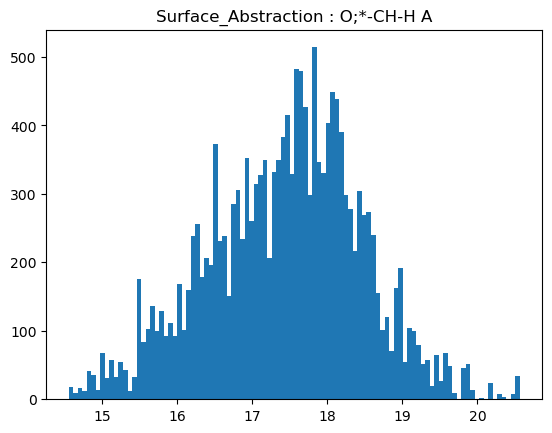

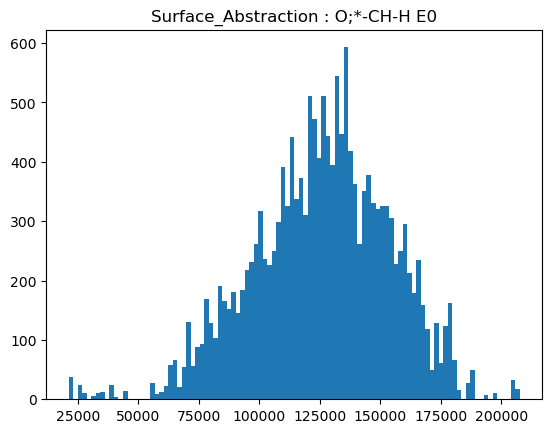

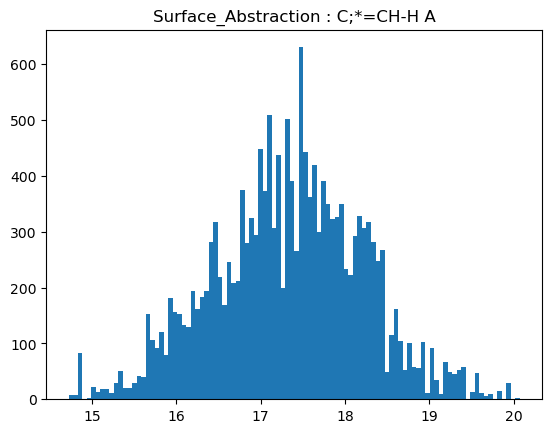

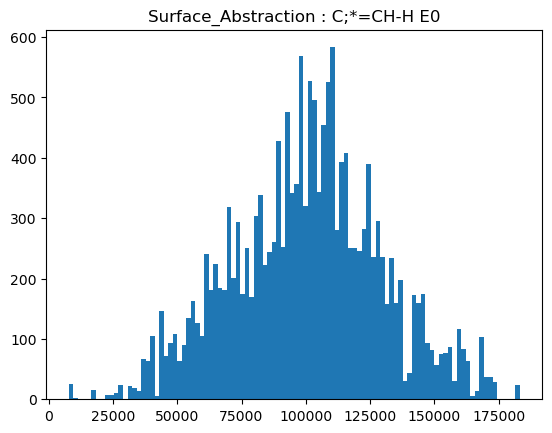

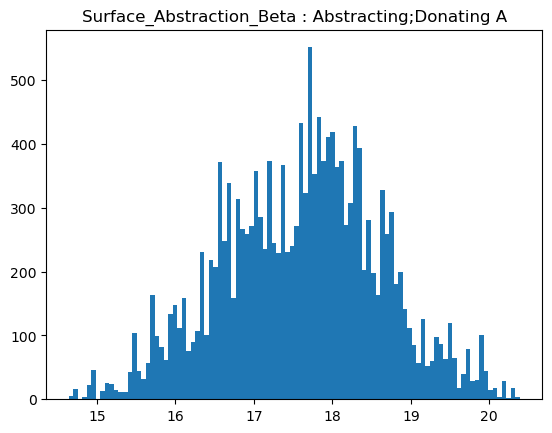

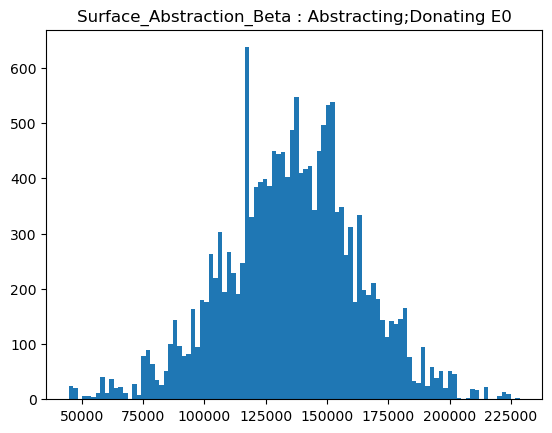

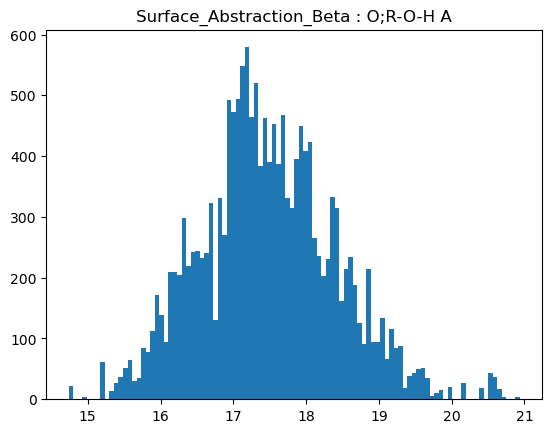

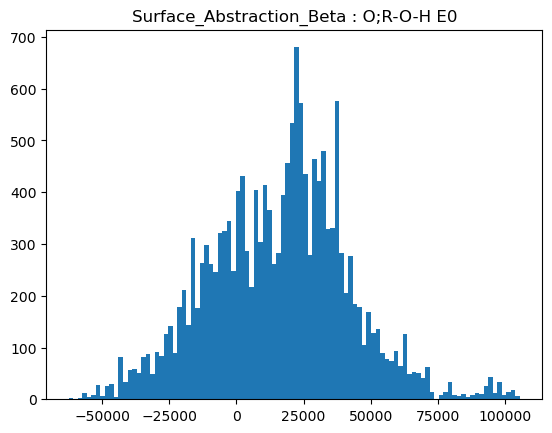

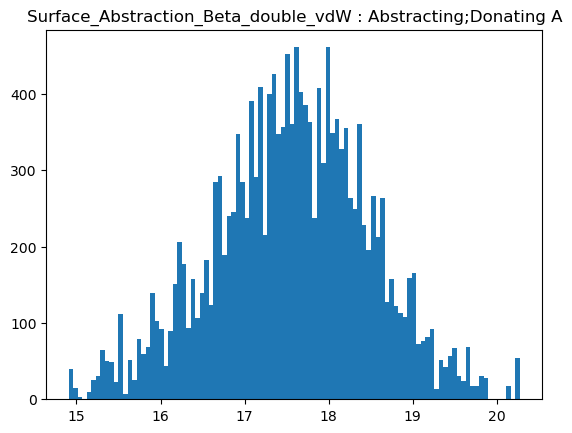

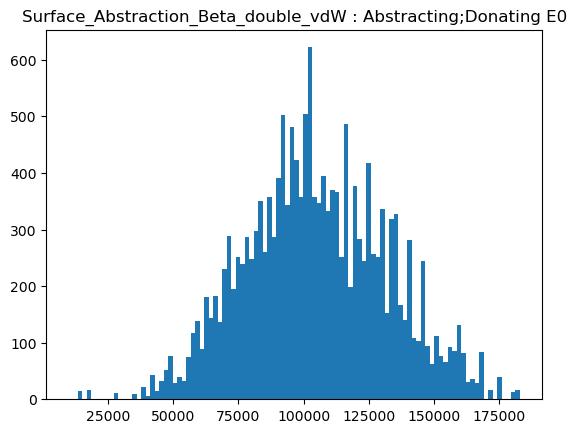

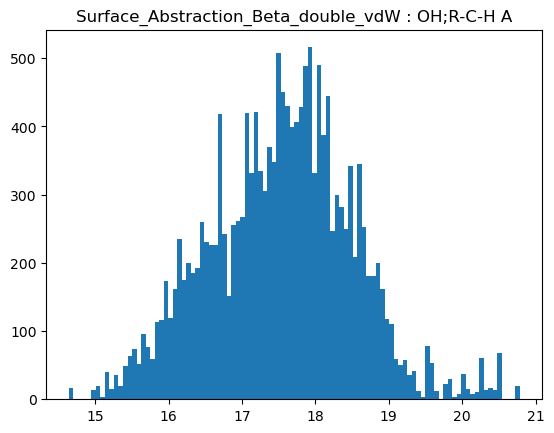

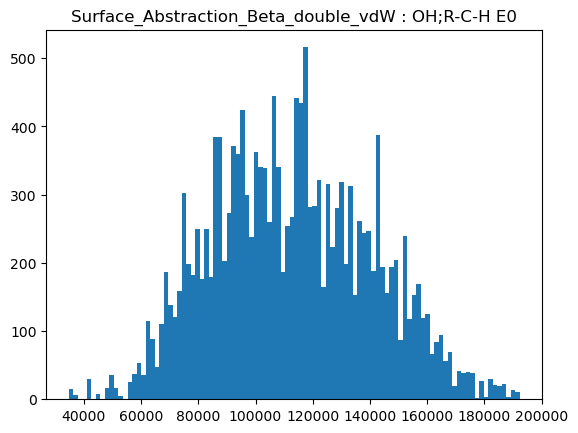

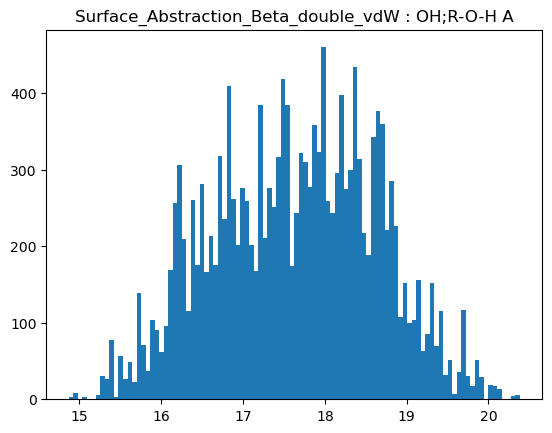

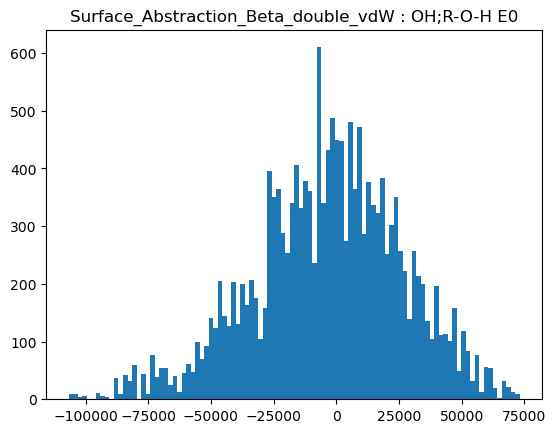

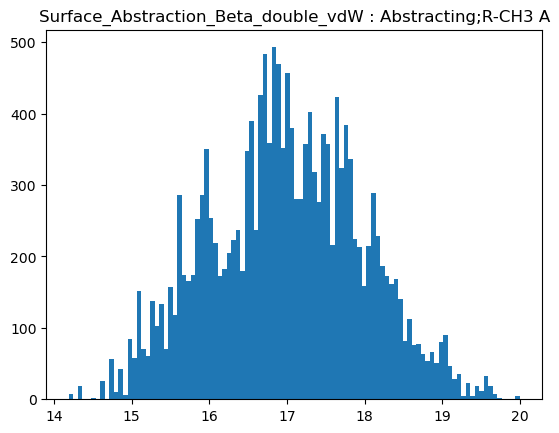

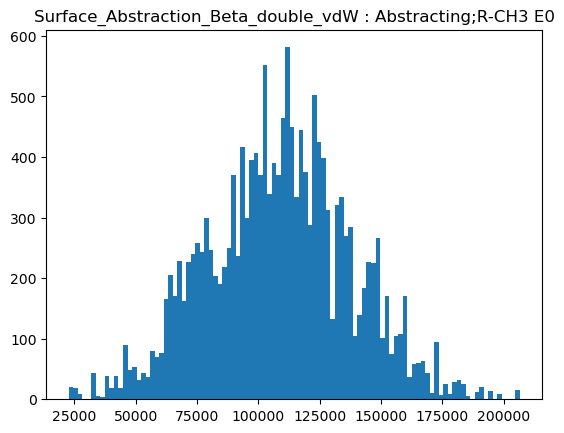

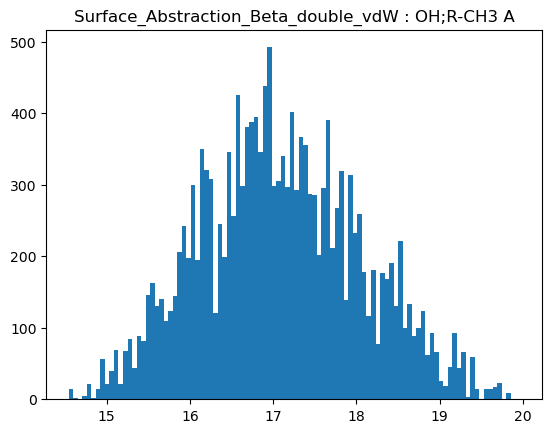

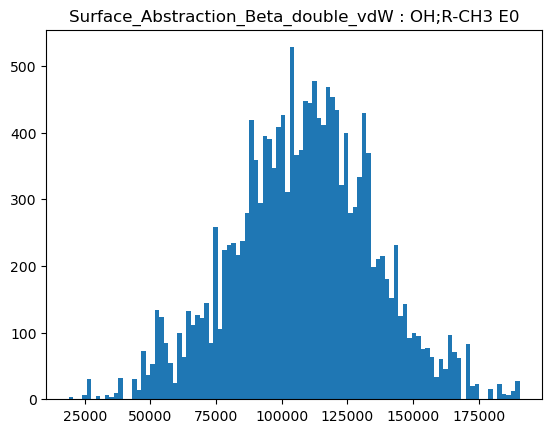

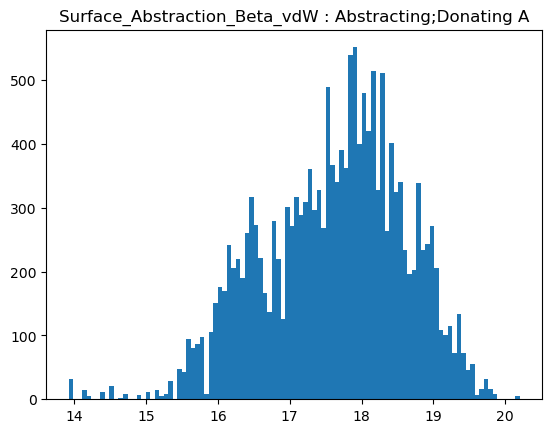

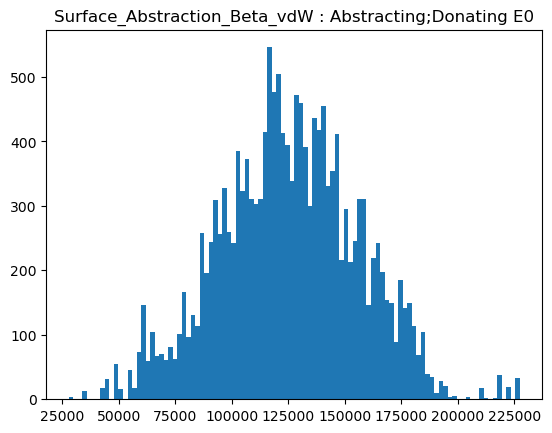

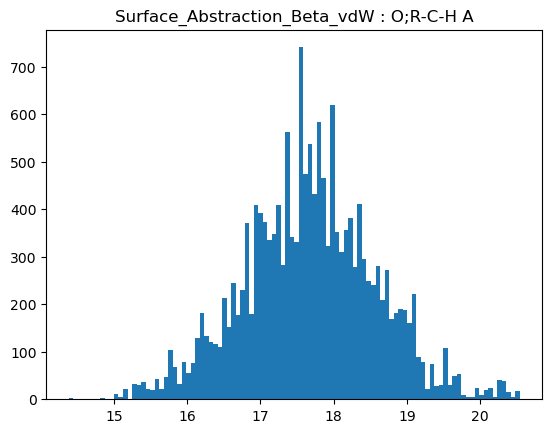

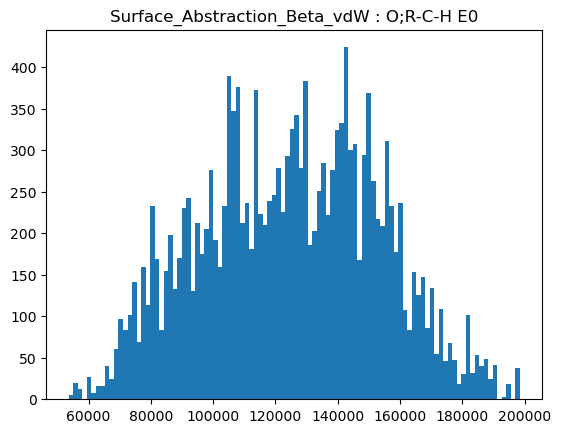

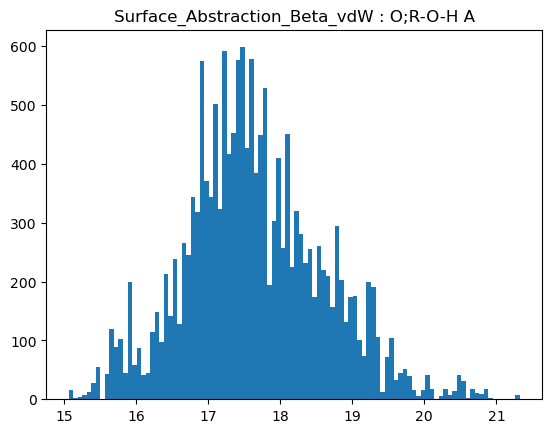

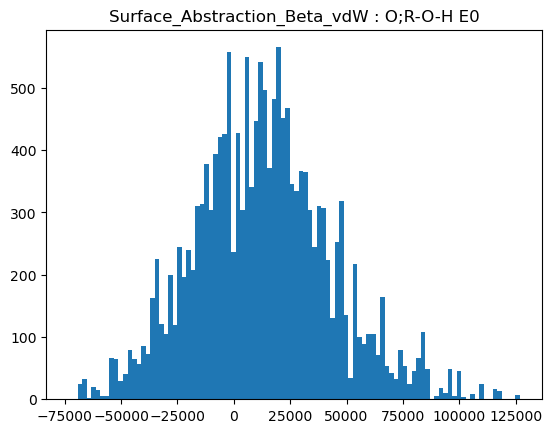

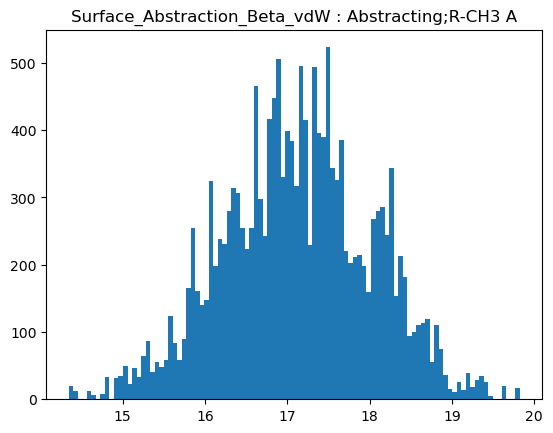

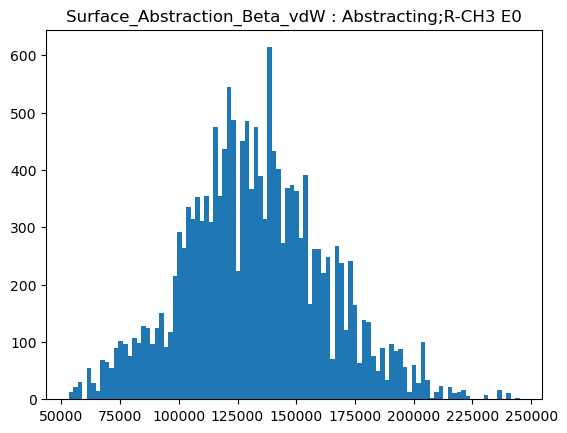

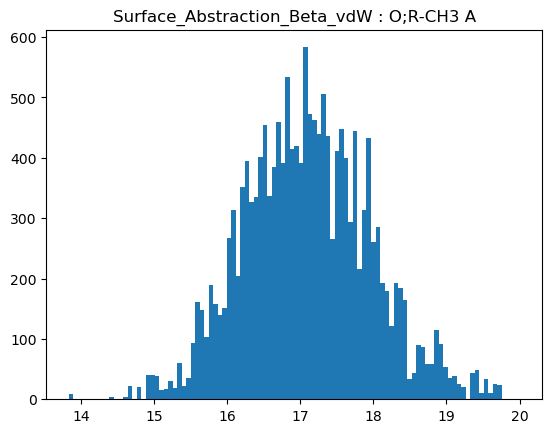

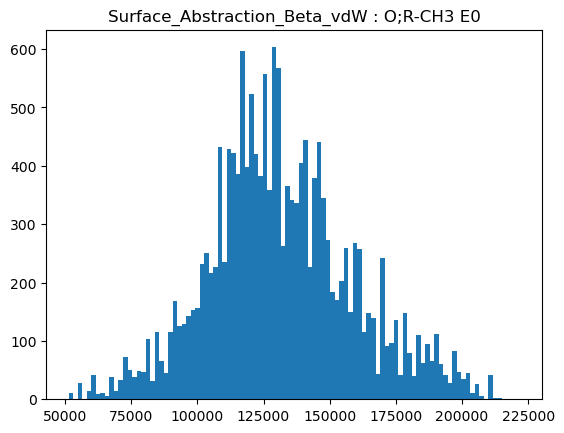

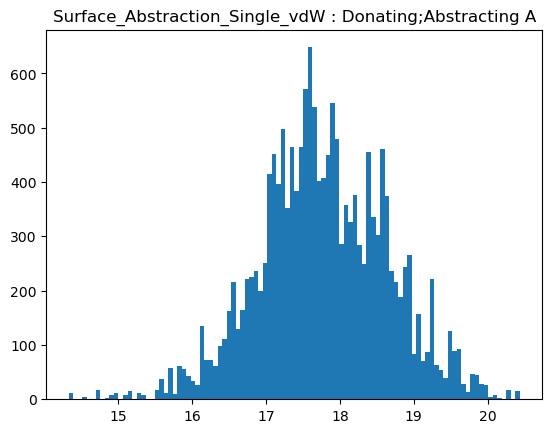

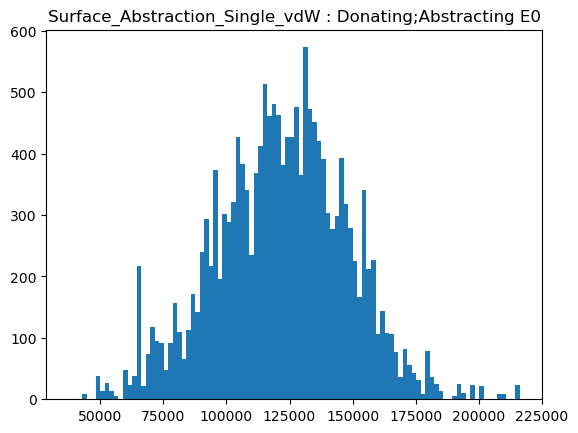

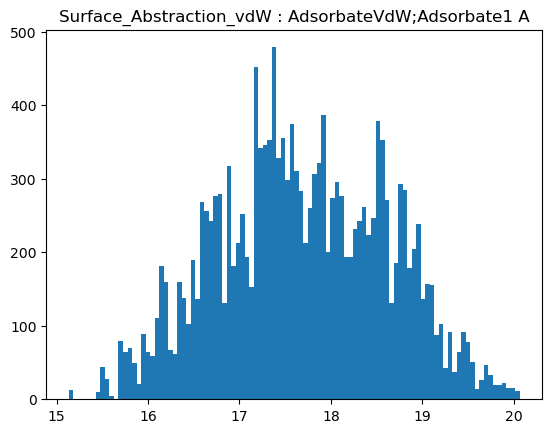

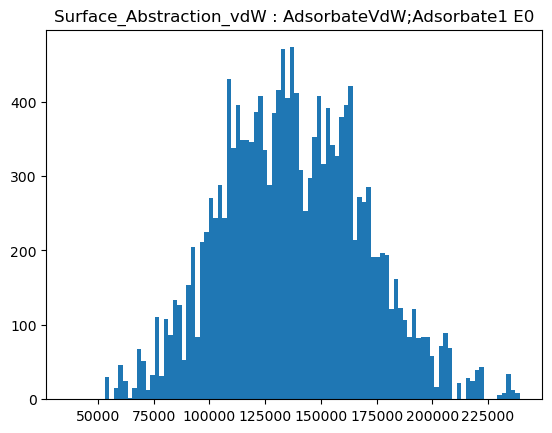

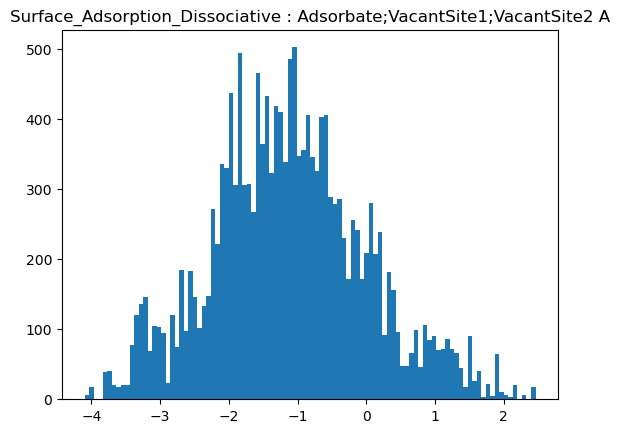

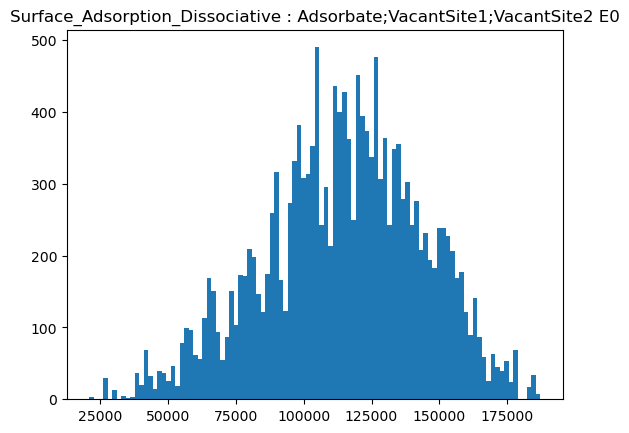

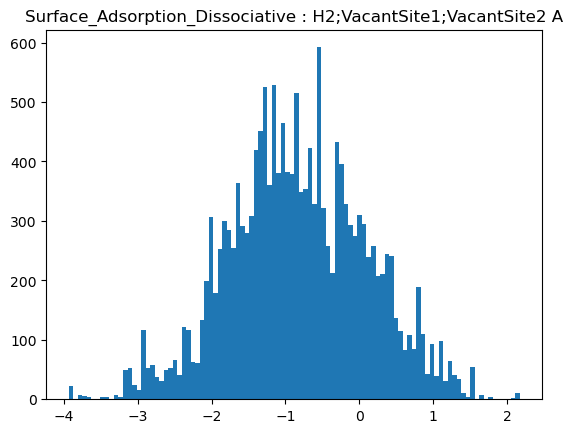

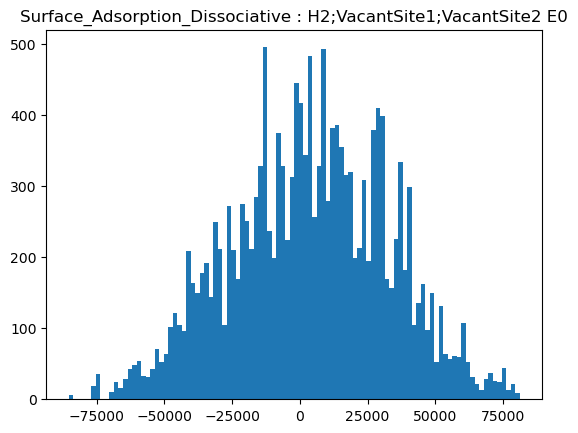

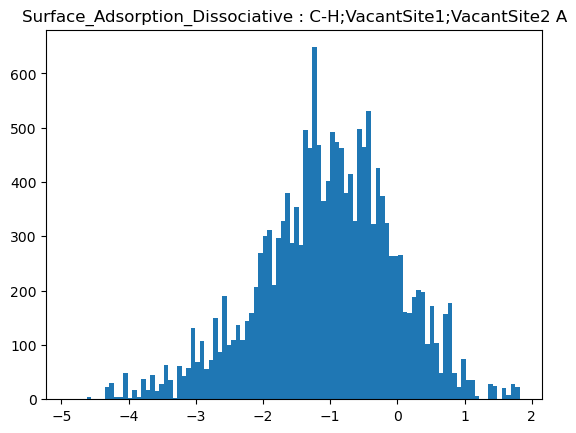

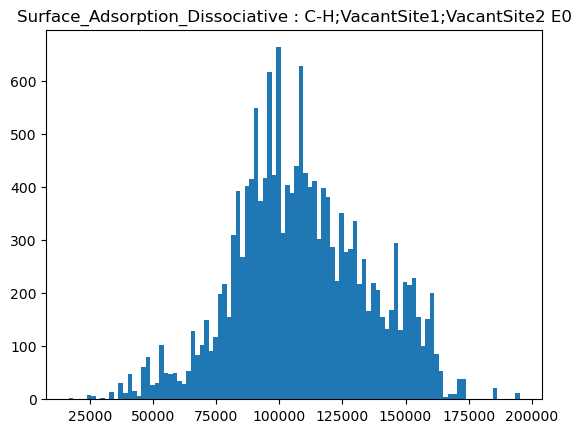

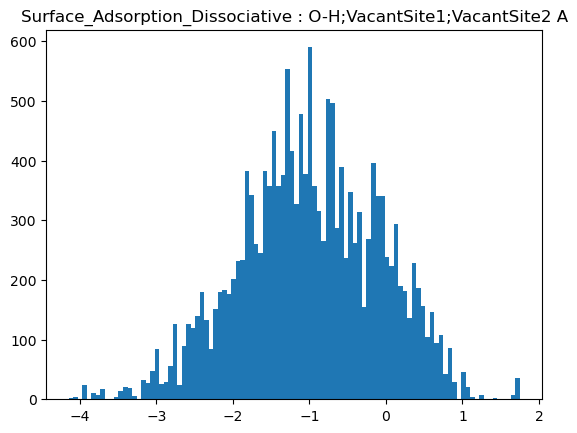

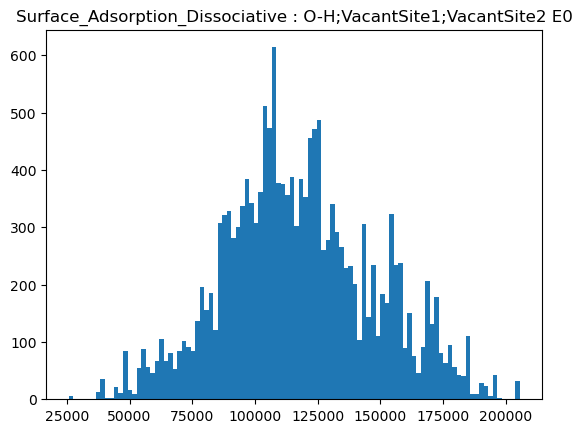

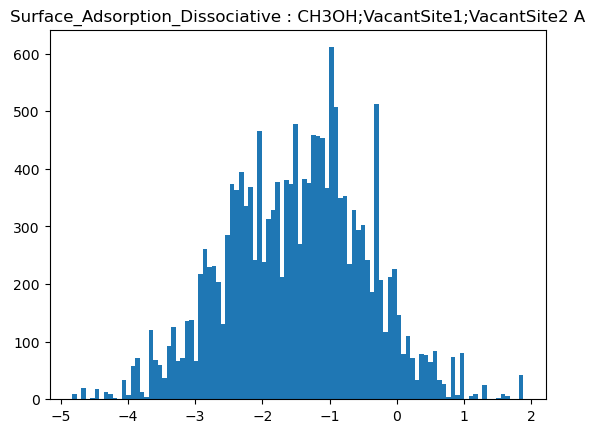

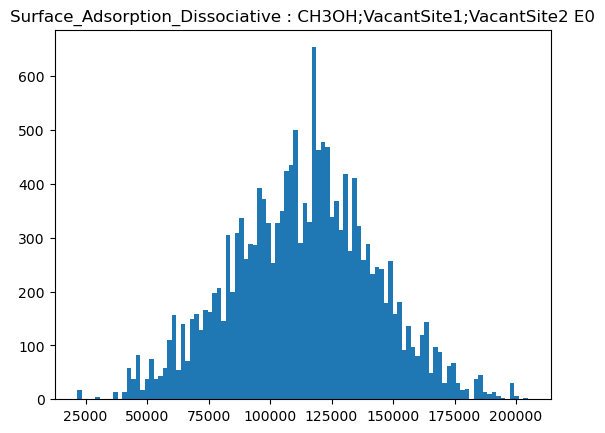

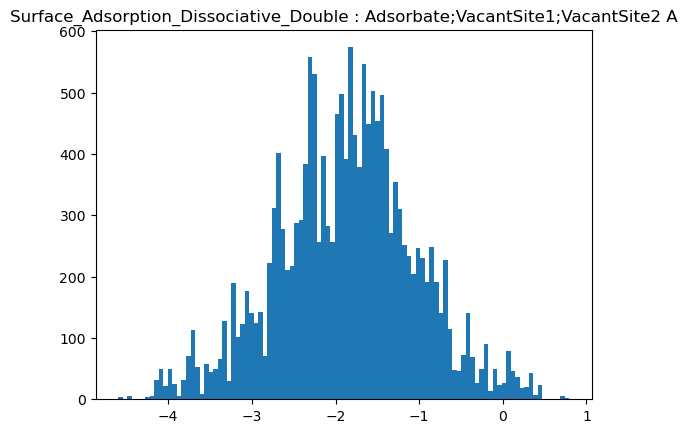

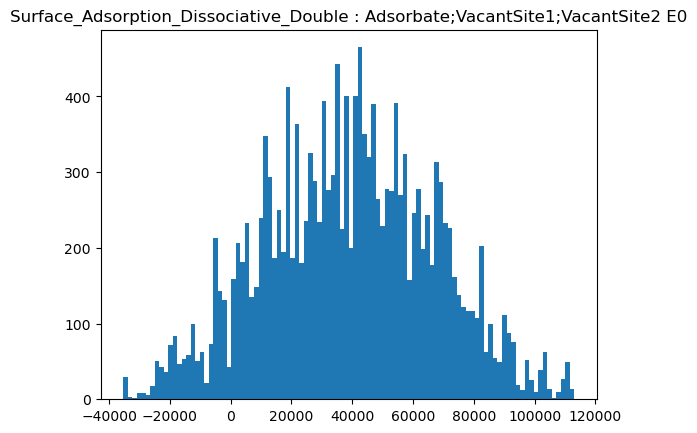

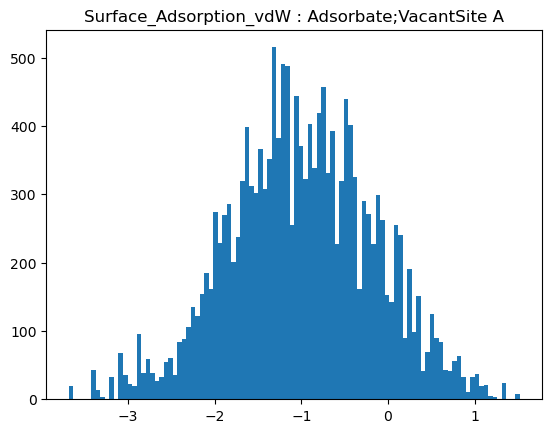

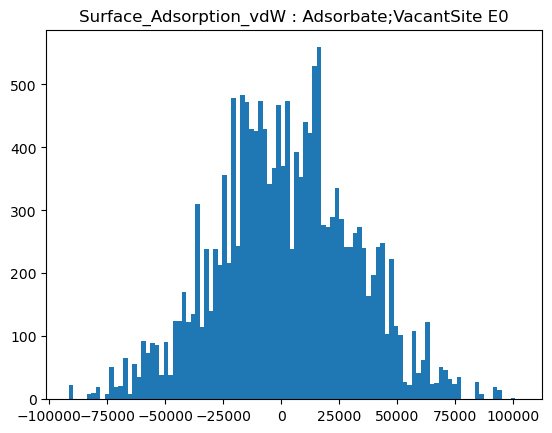

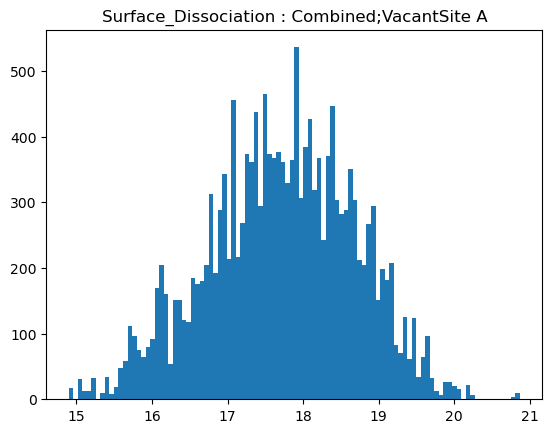

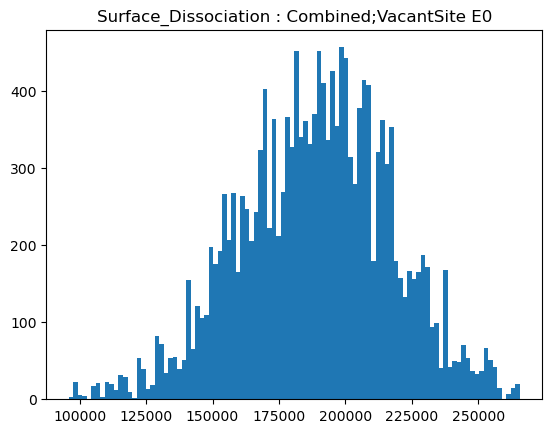

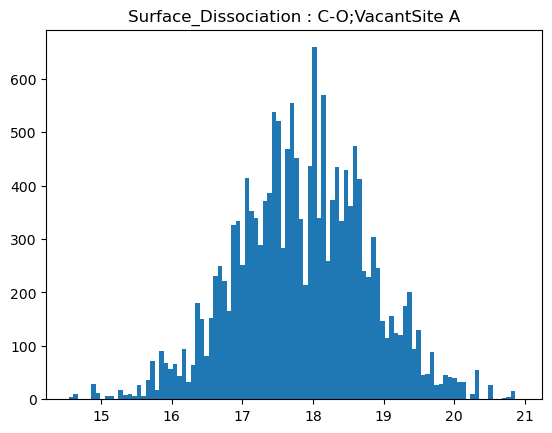

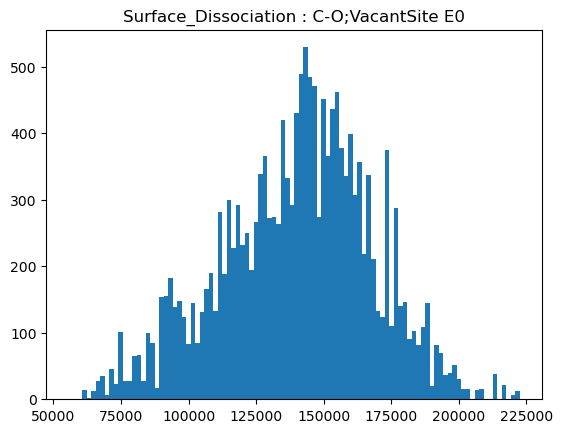

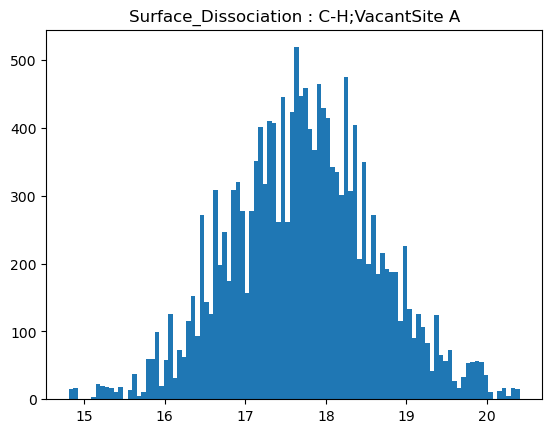

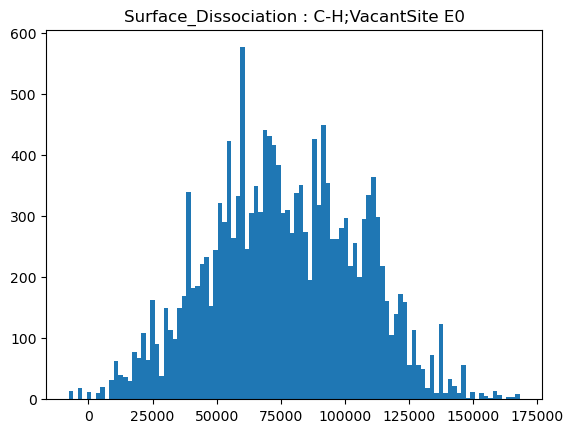

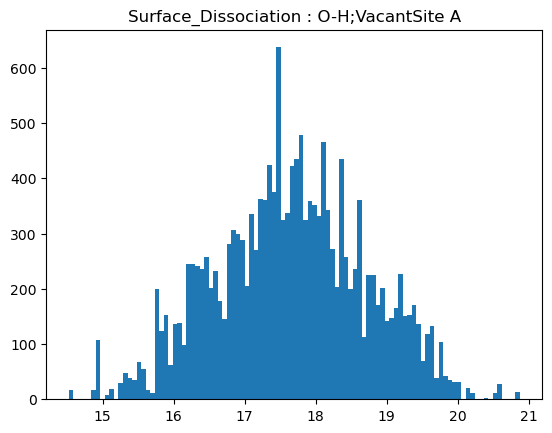

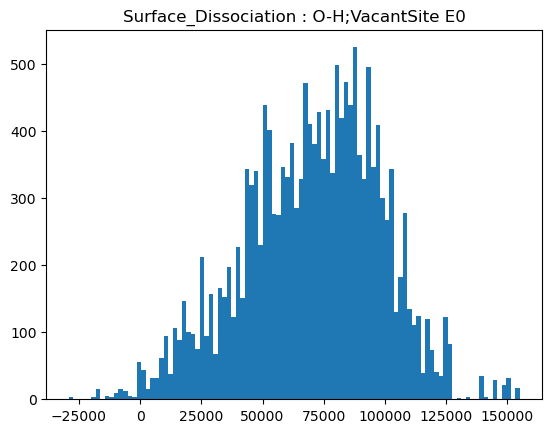

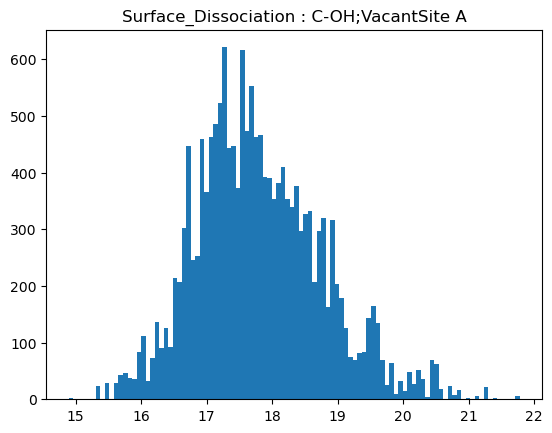

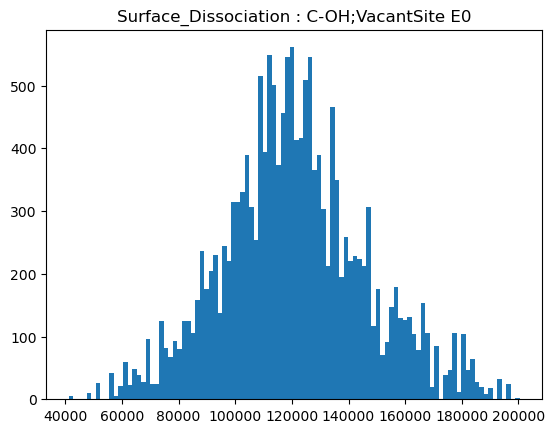

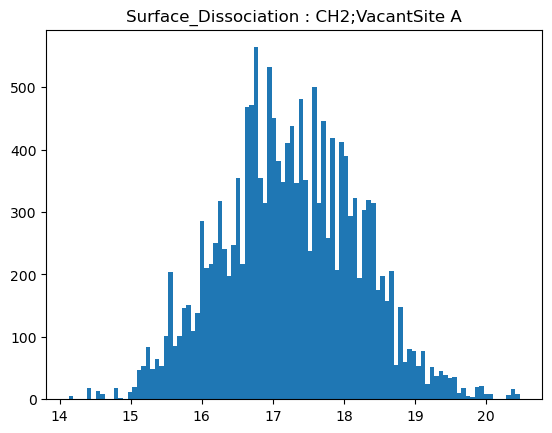

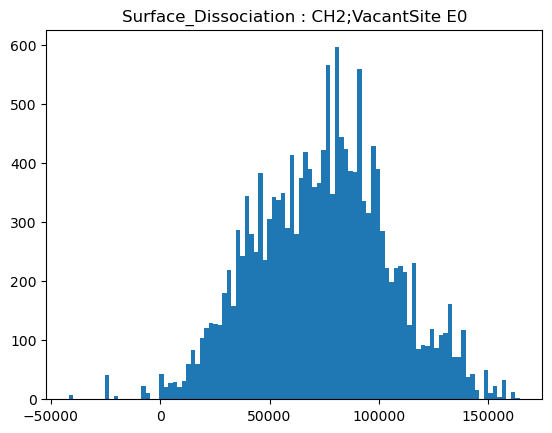

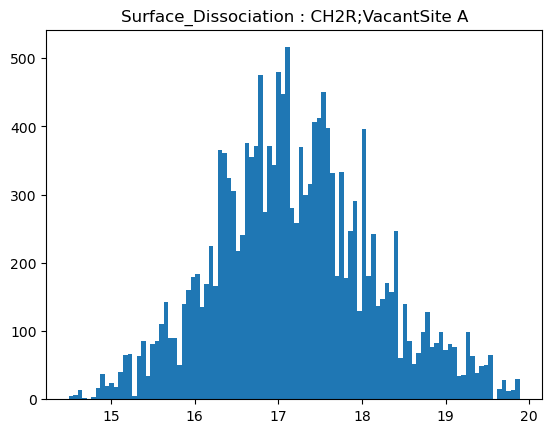

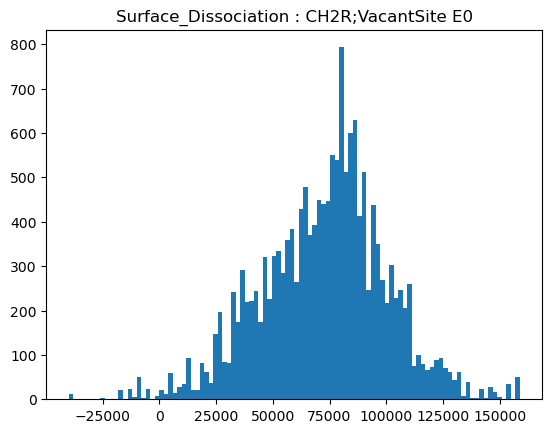

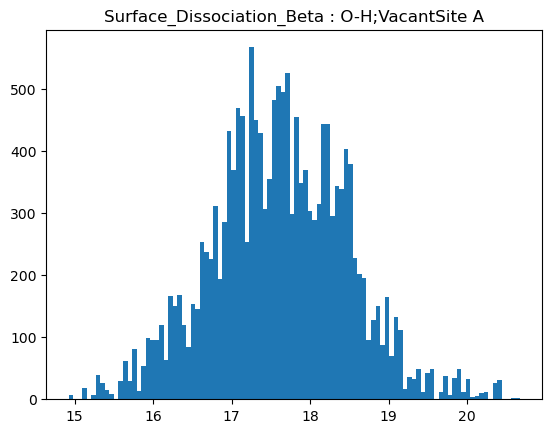

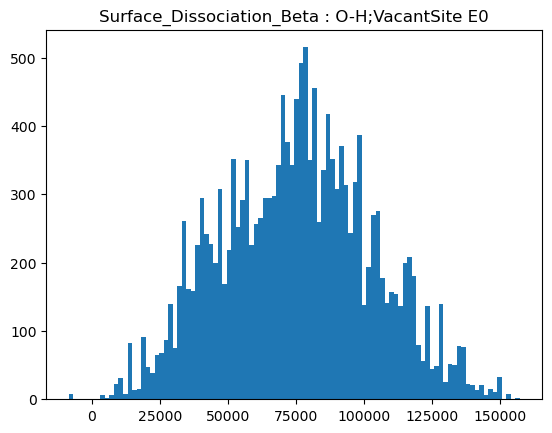

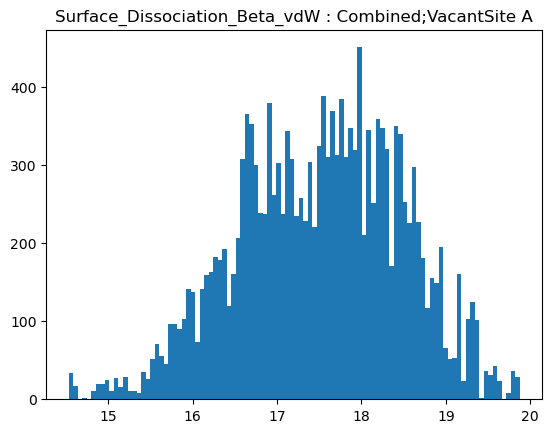

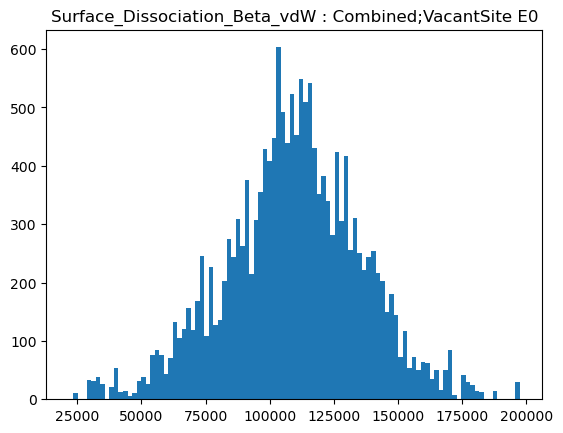

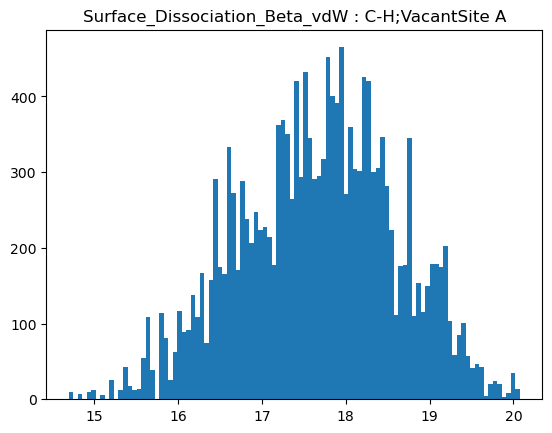

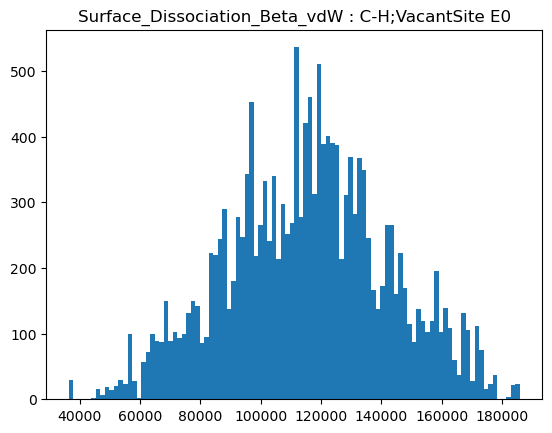

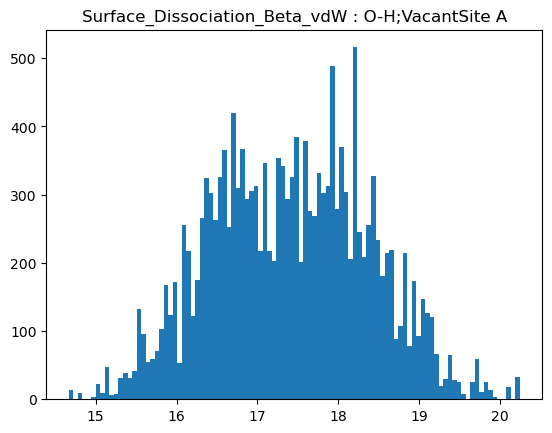

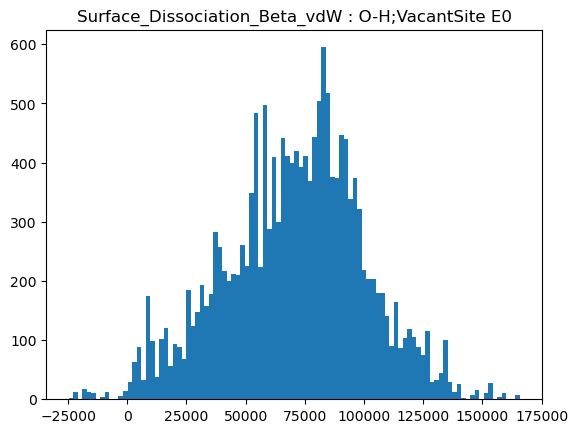

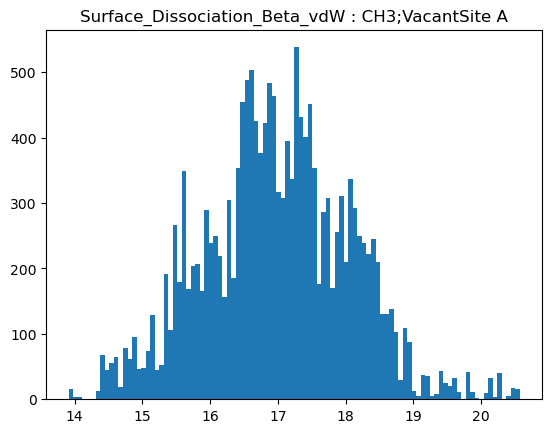

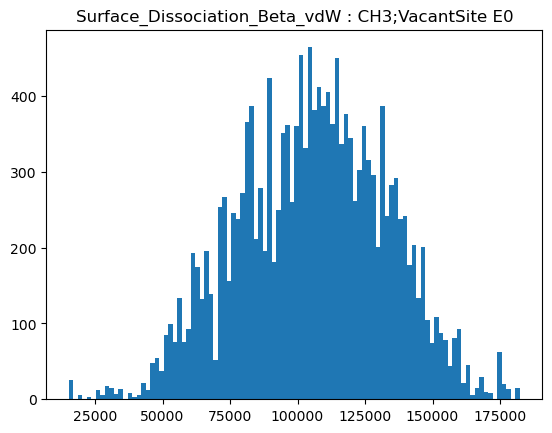

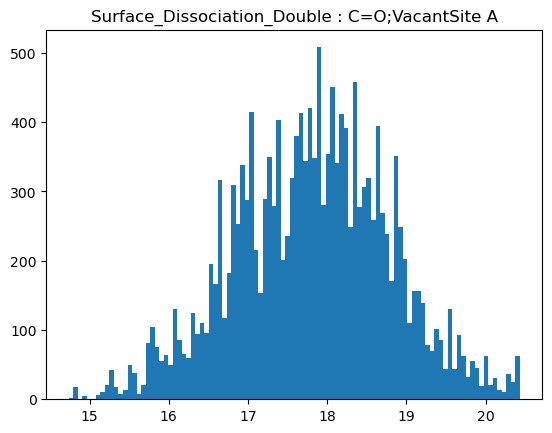

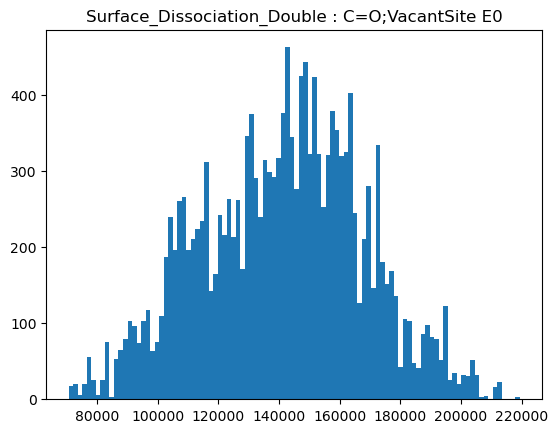

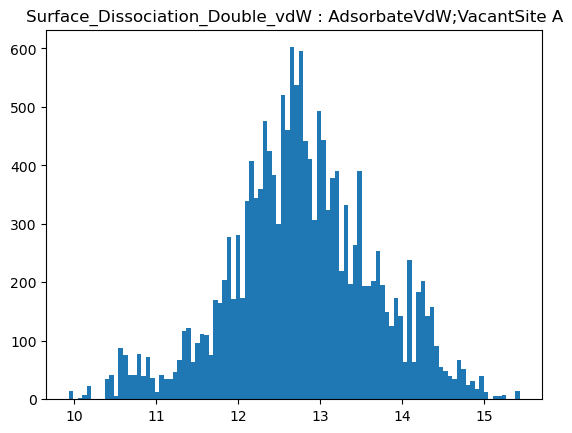

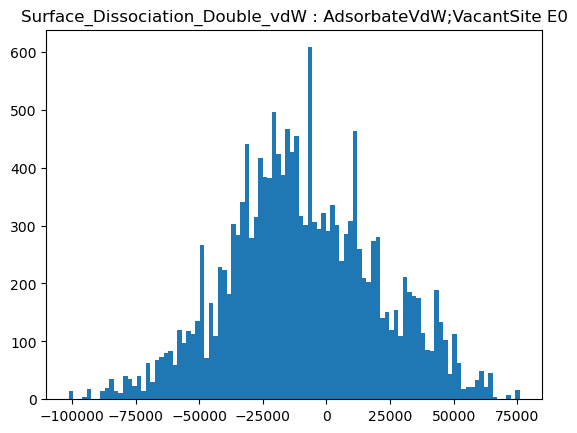

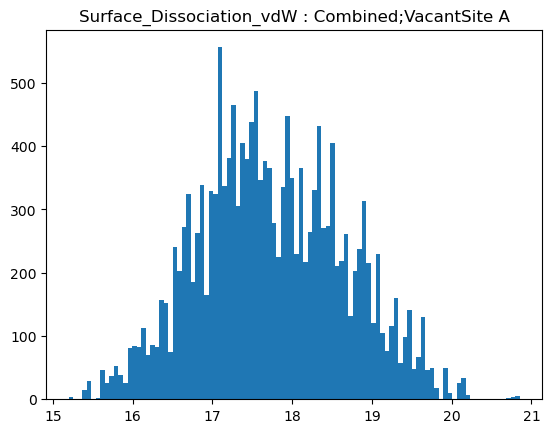

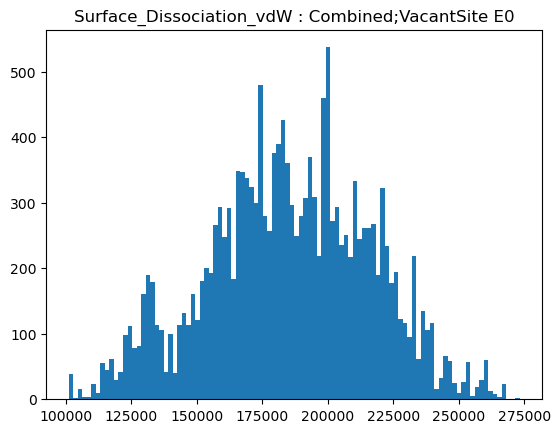

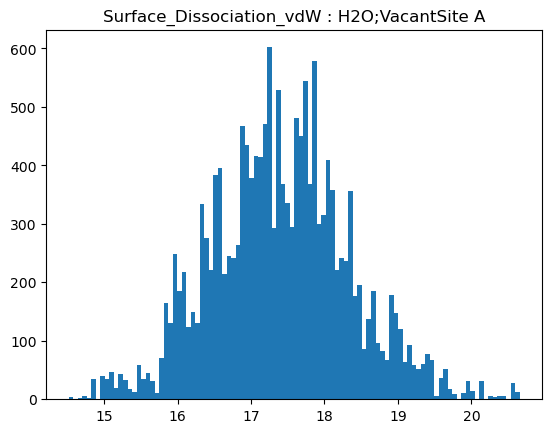

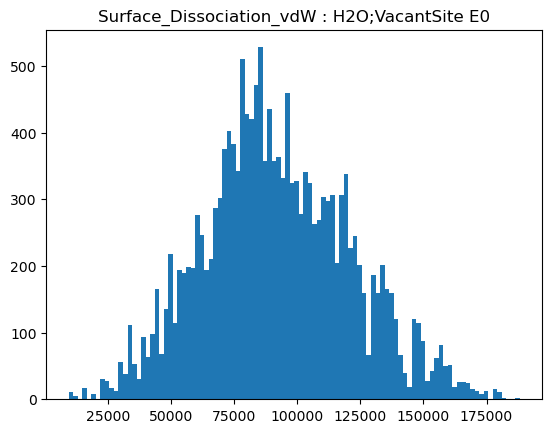

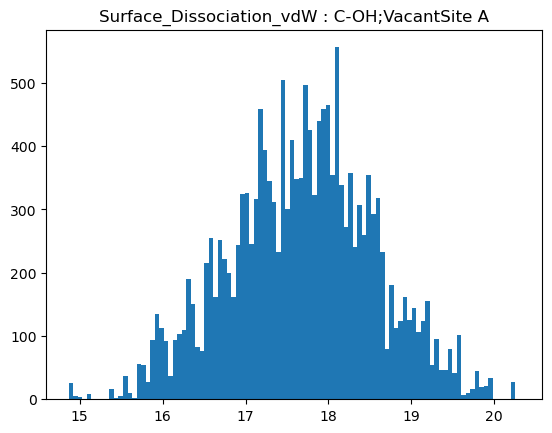

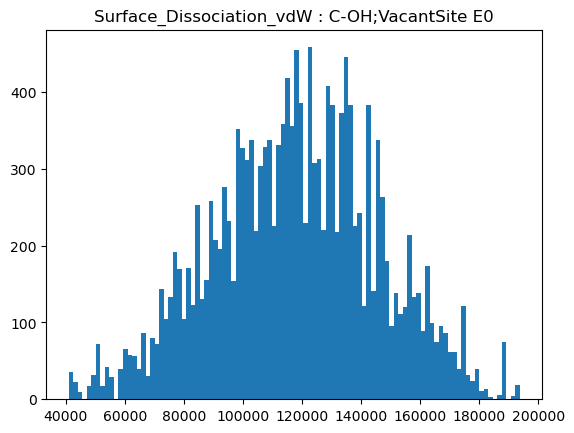

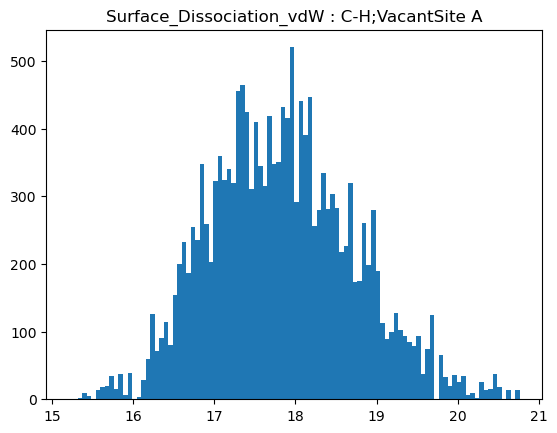

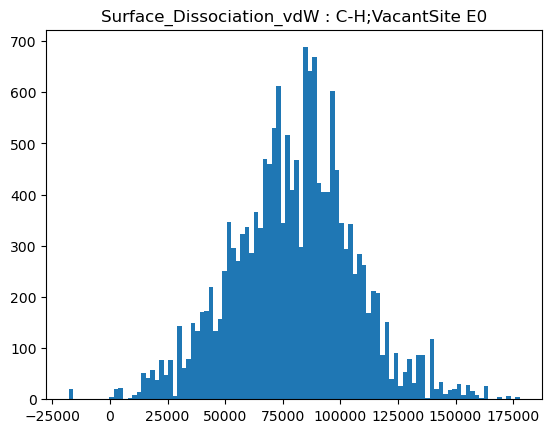

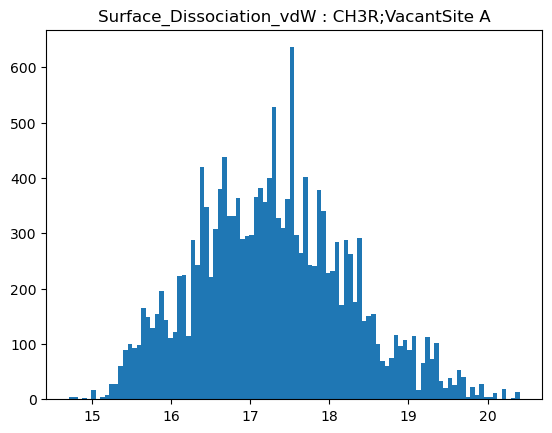

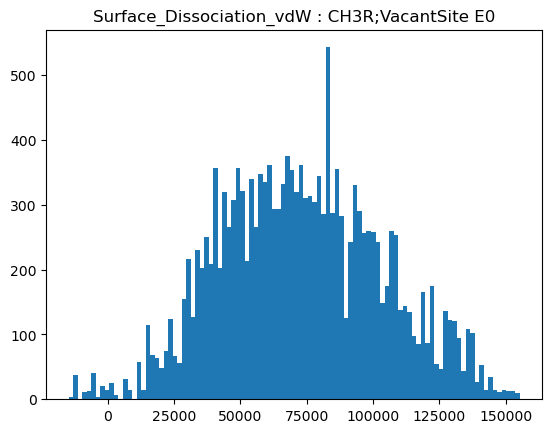

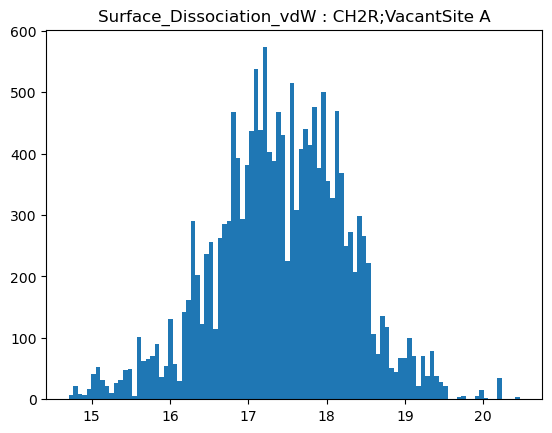

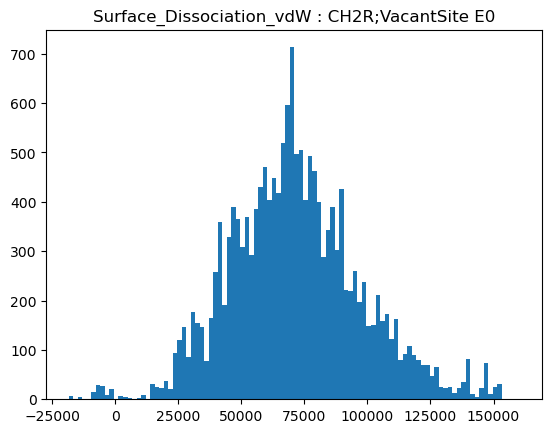

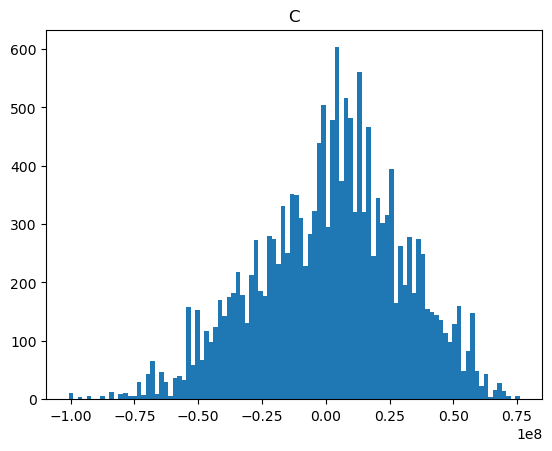

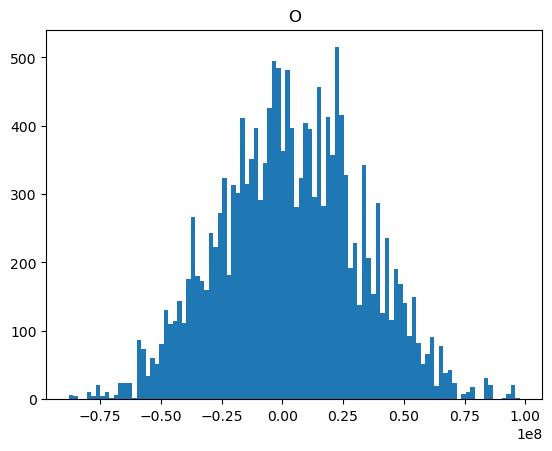

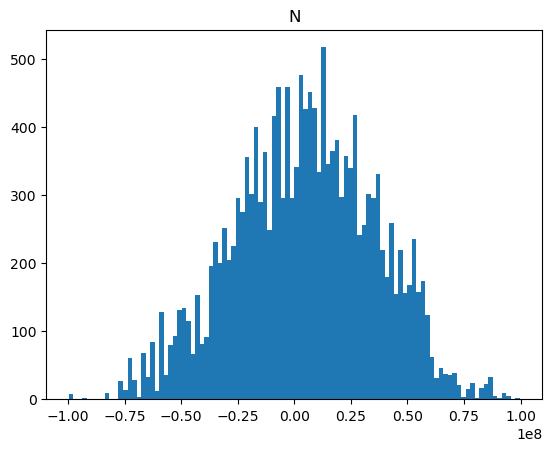

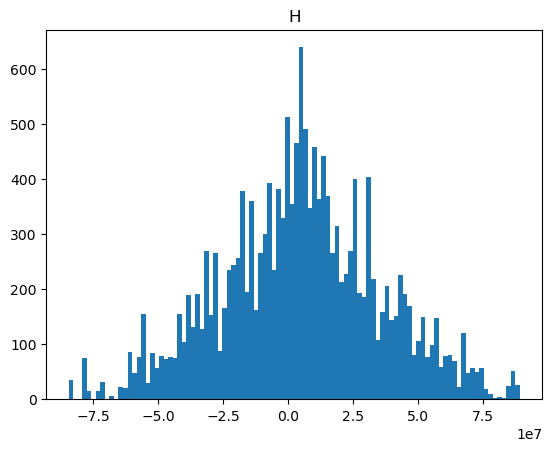

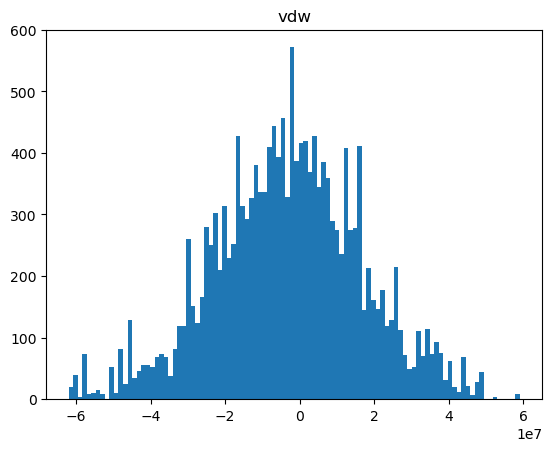

In [37]:
pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/pe_object.dill"
# pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/pe_object.dill"
# pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/pe_object.dill"
# pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/pe_object.dill"
pe_object = PEUQSE.load_PE_object(pic_path)

# first, load the run with the highest logp:
param_values = pe_object.map_parameter_set
names = list(pe_object.UserInput.parameterNamesAndMathTypeExpressionsDict.keys())
for val in range(len(pe_object.post_burn_in_samples[0])):
    
    plt.clf()
    plt.title(names[val])
    plt.hist(pe_object.post_burn_in_samples[:,val], bins = 100)
    plt.show()

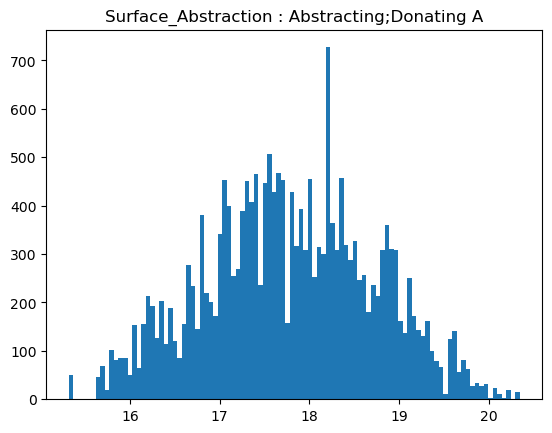

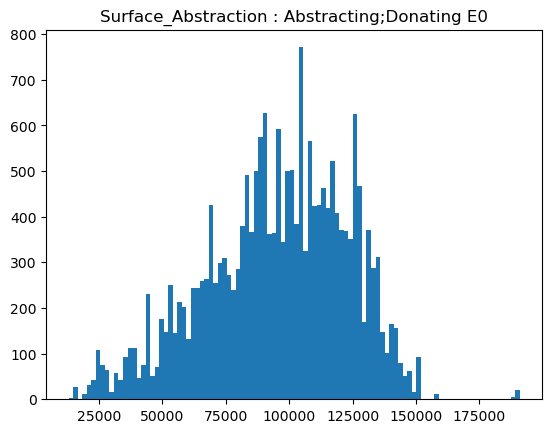

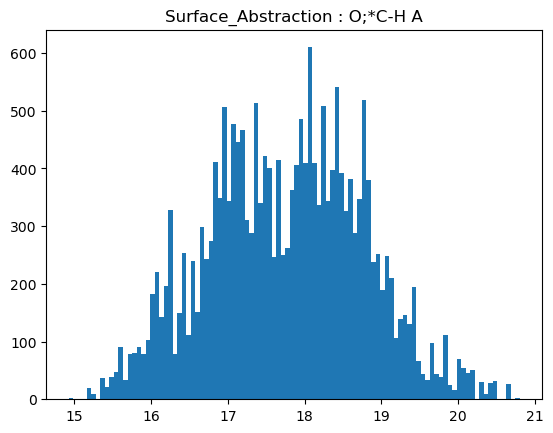

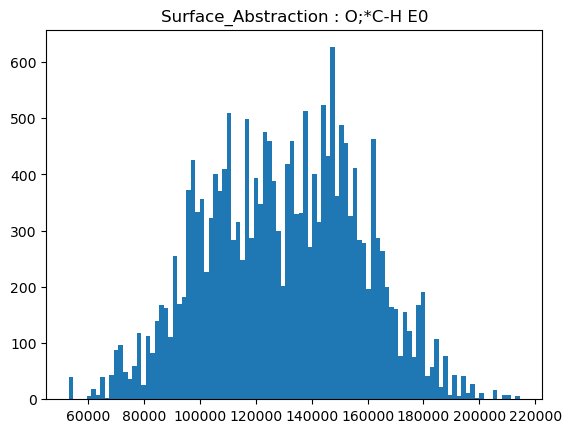

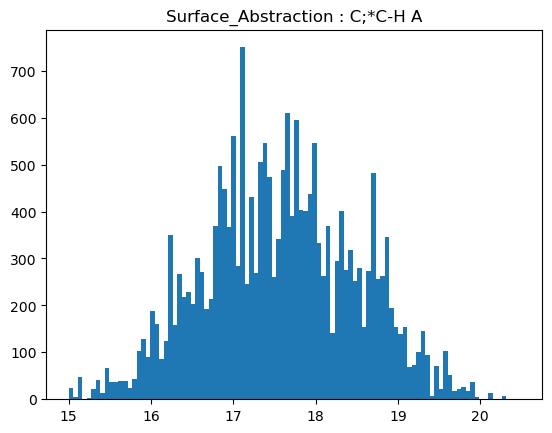

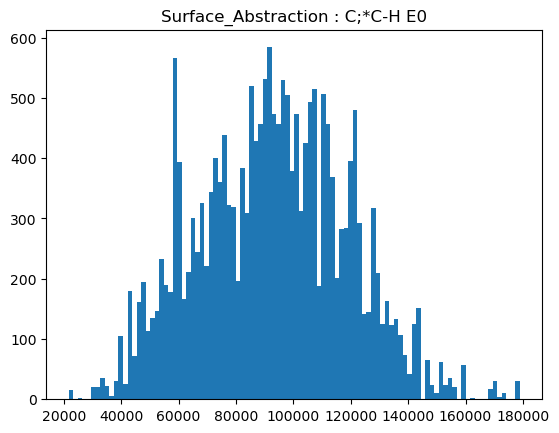

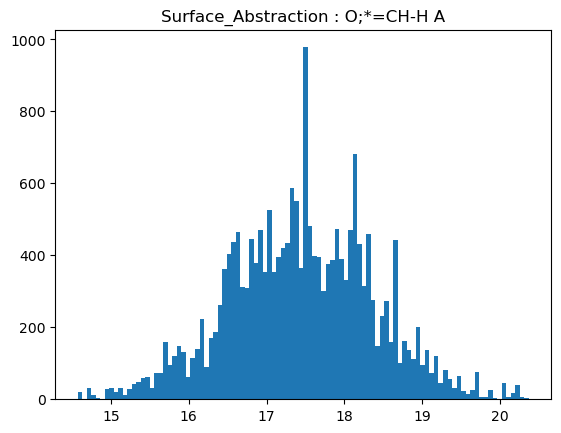

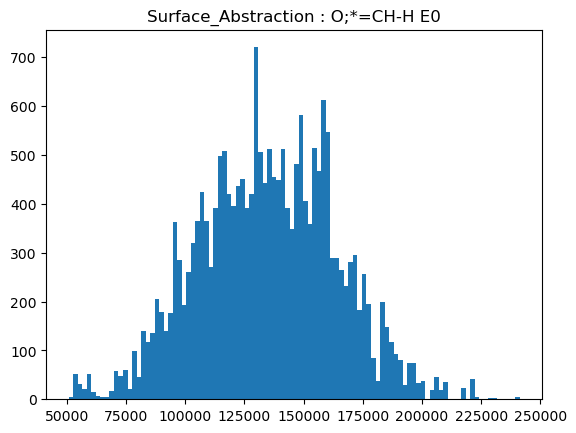

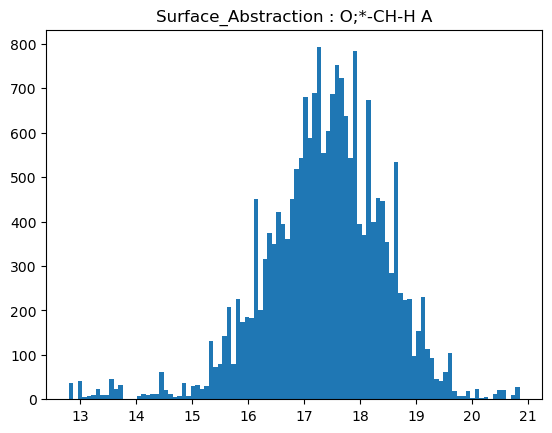

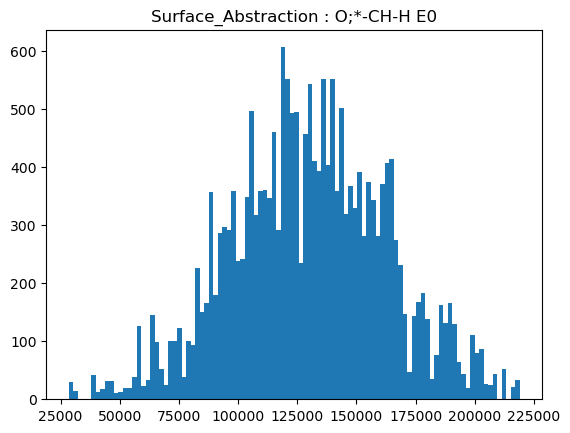

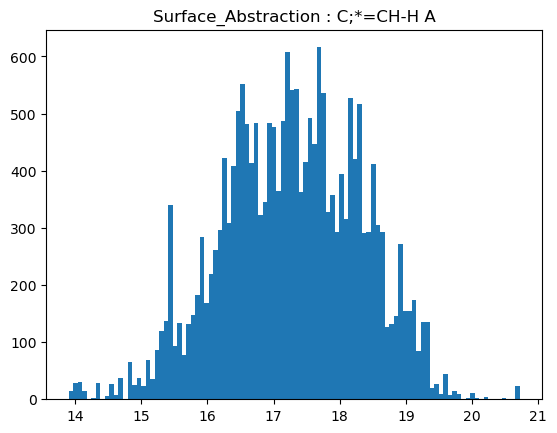

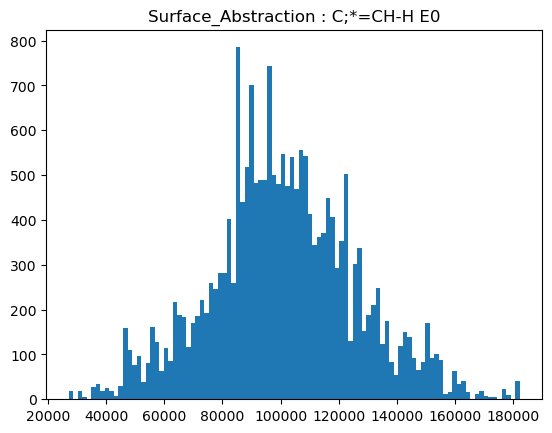

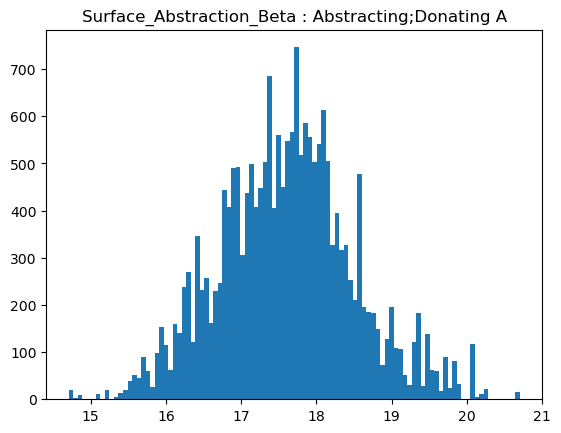

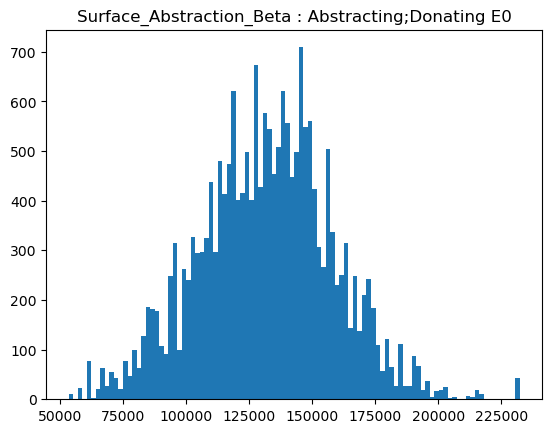

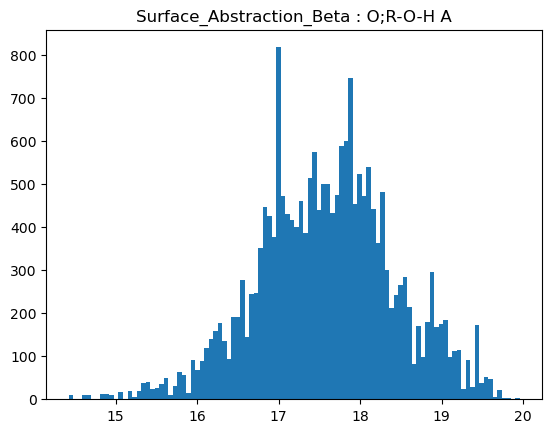

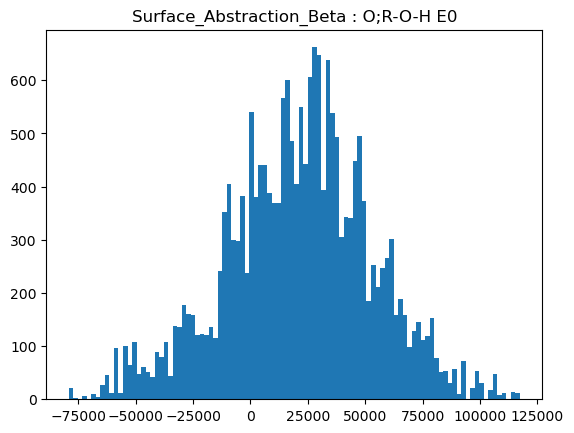

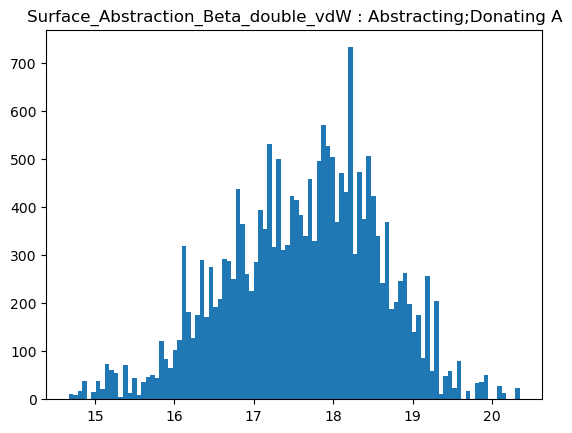

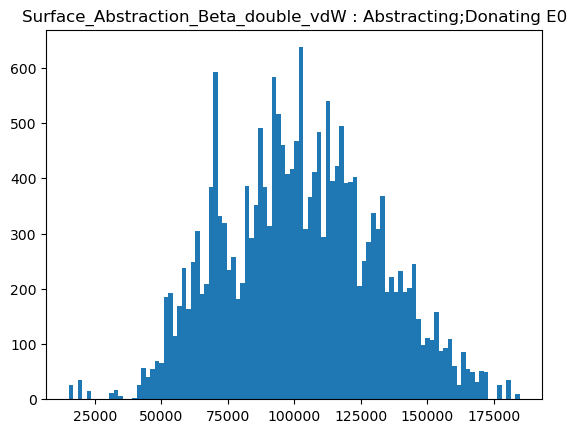

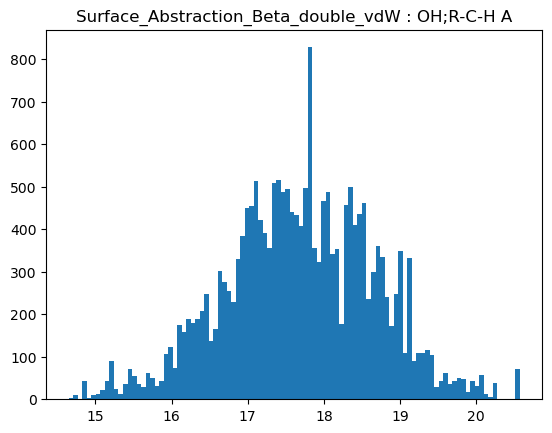

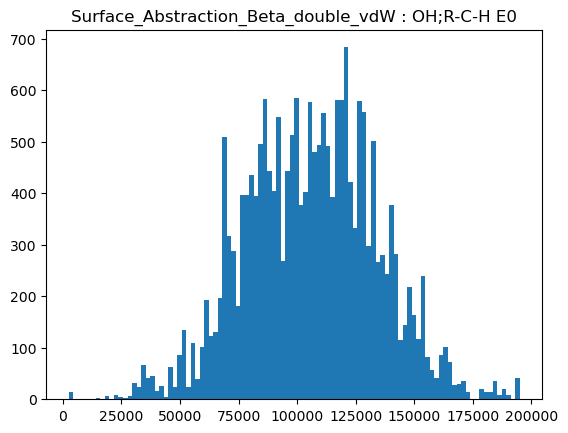

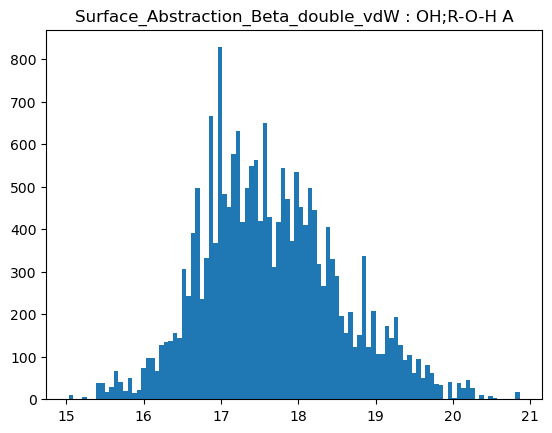

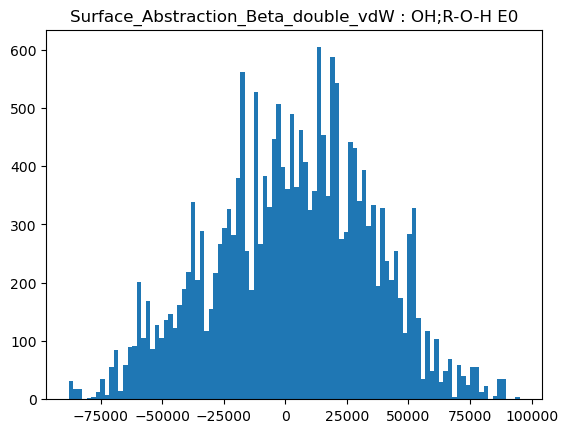

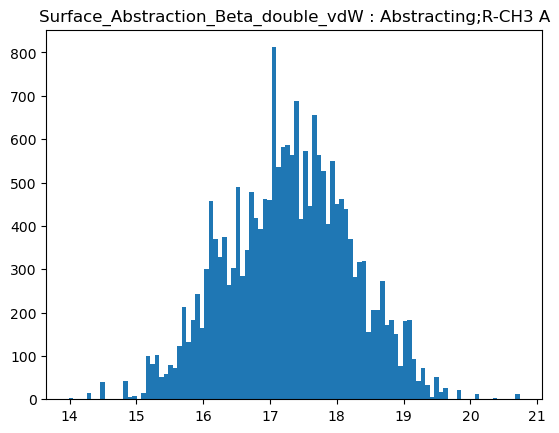

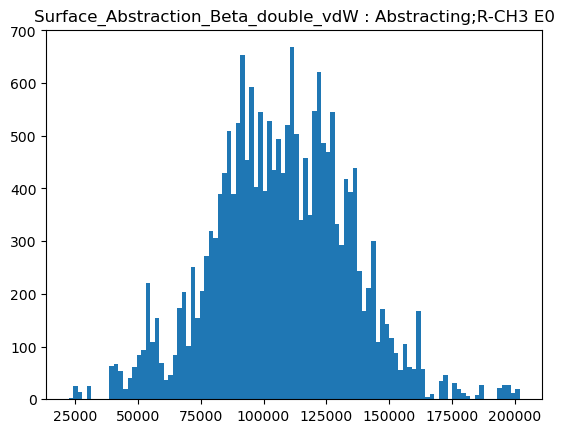

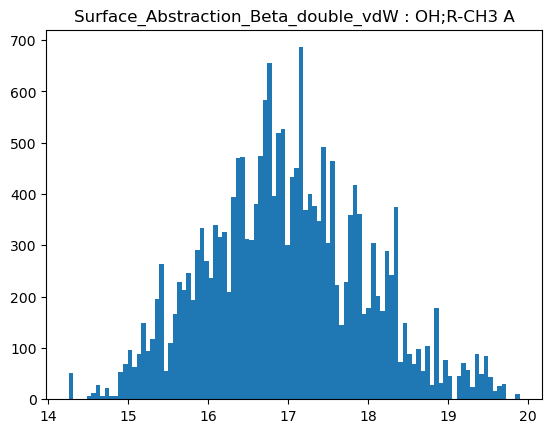

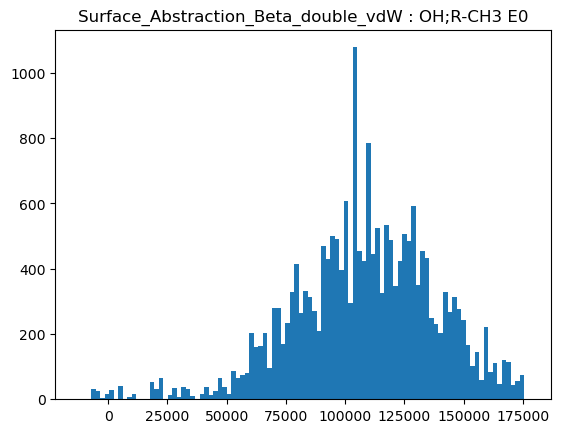

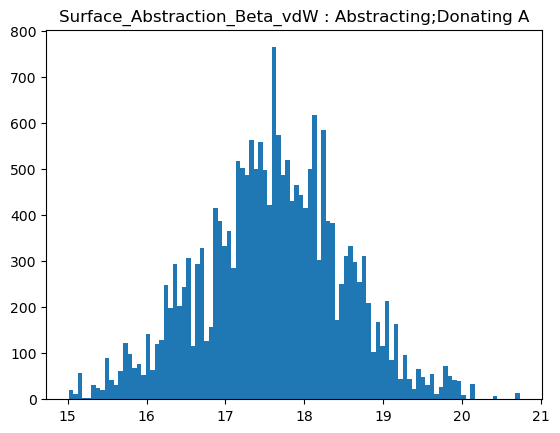

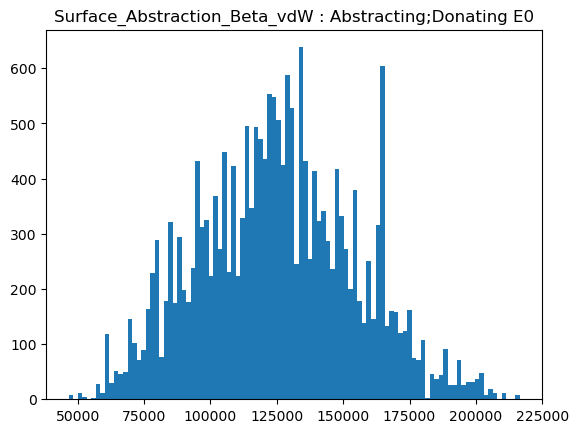

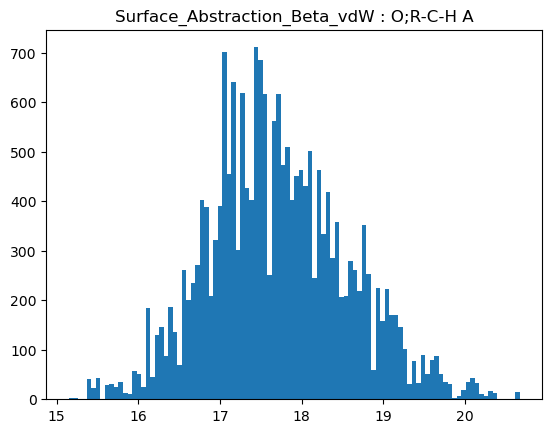

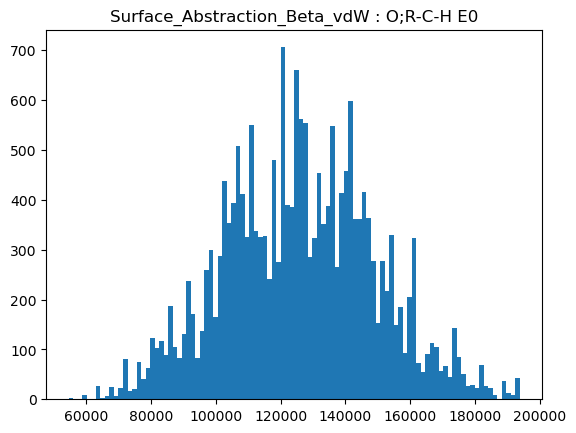

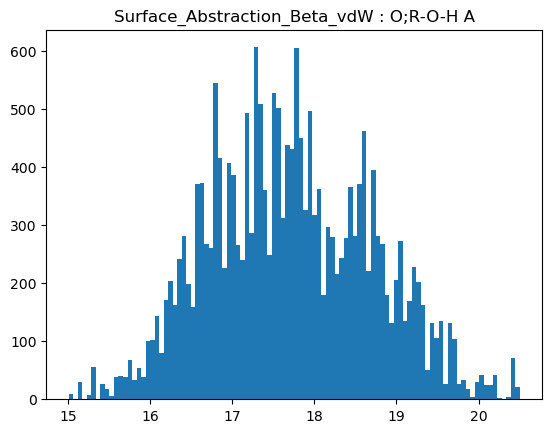

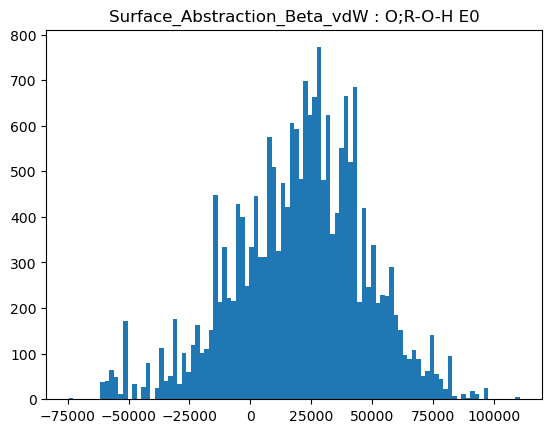

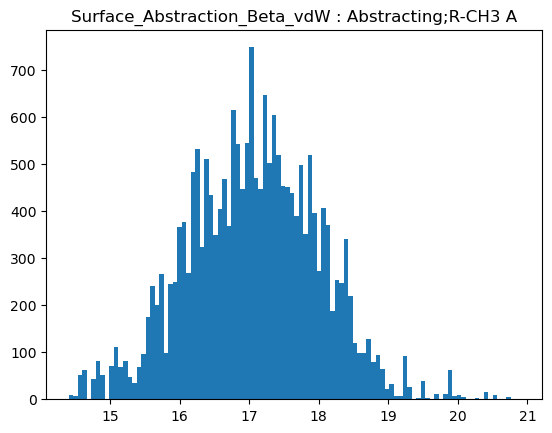

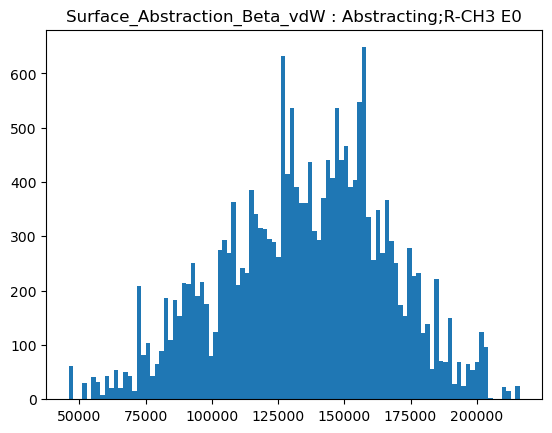

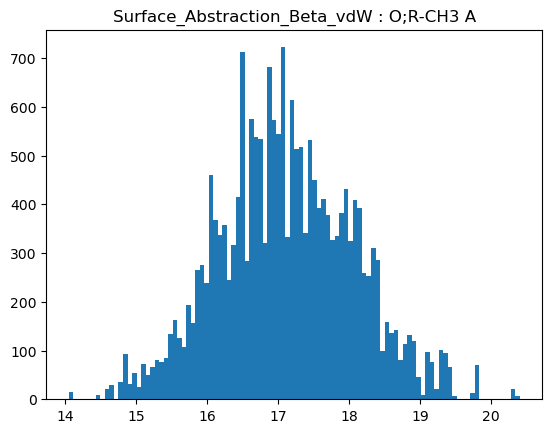

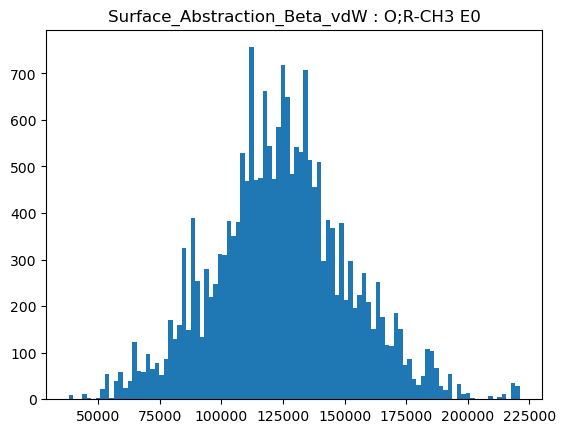

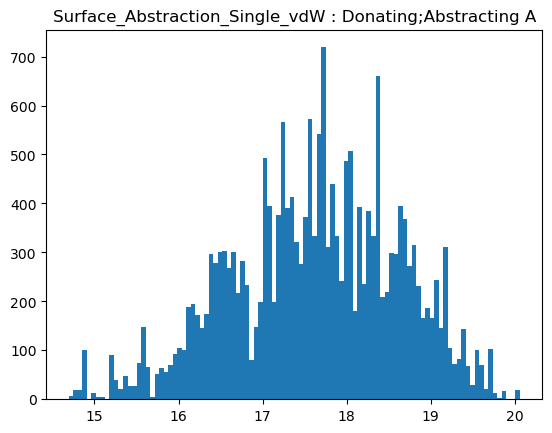

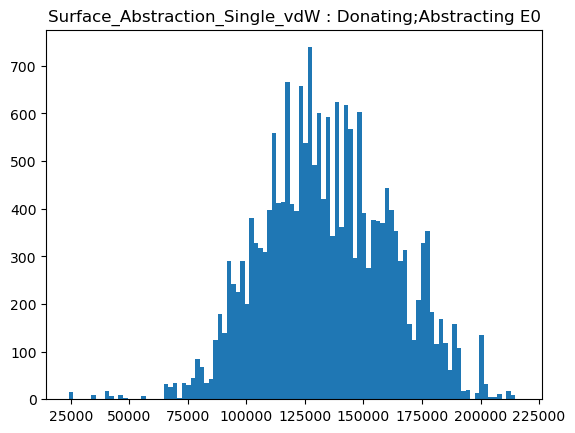

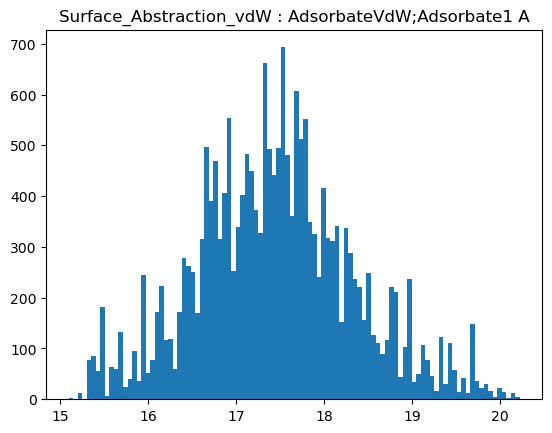

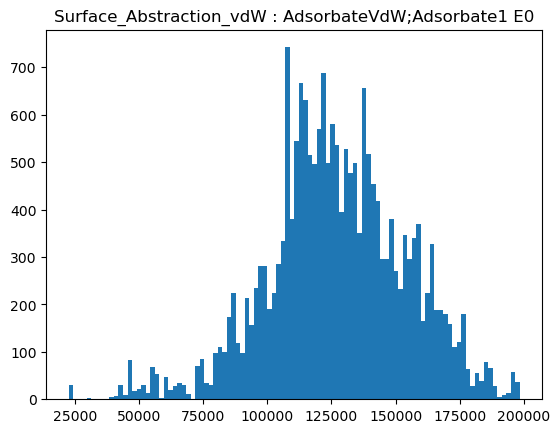

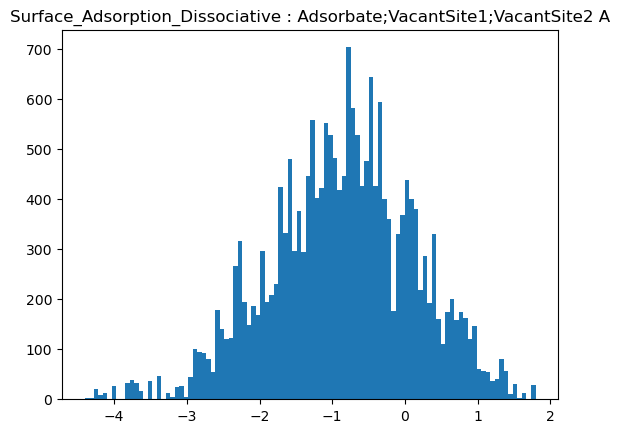

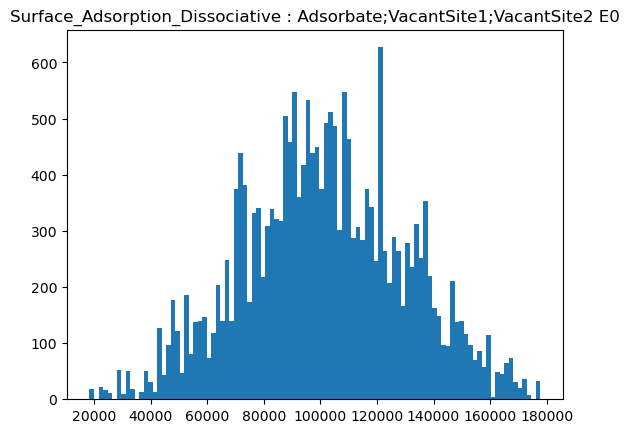

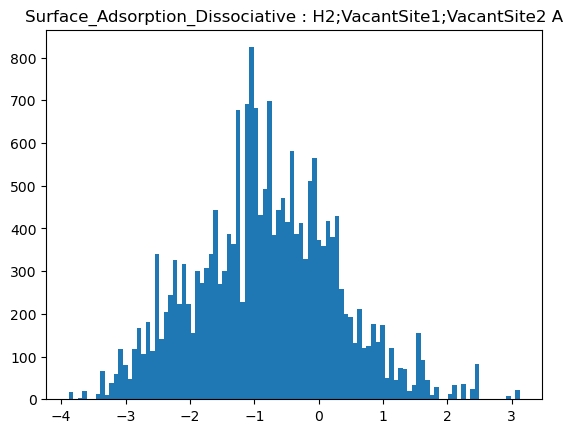

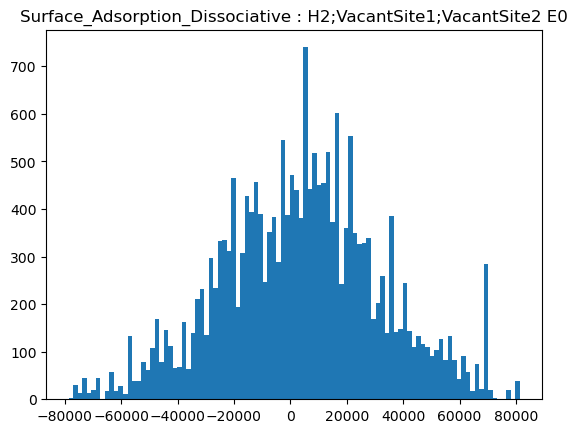

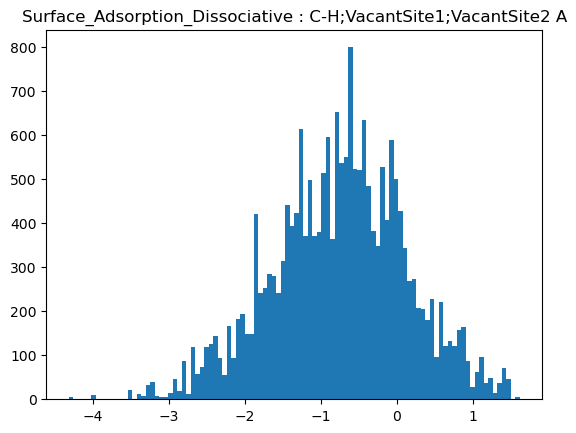

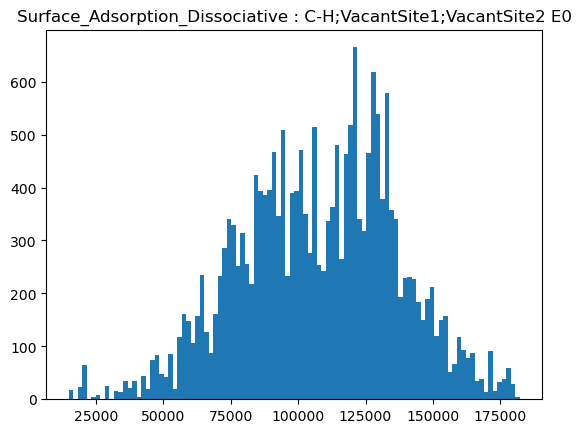

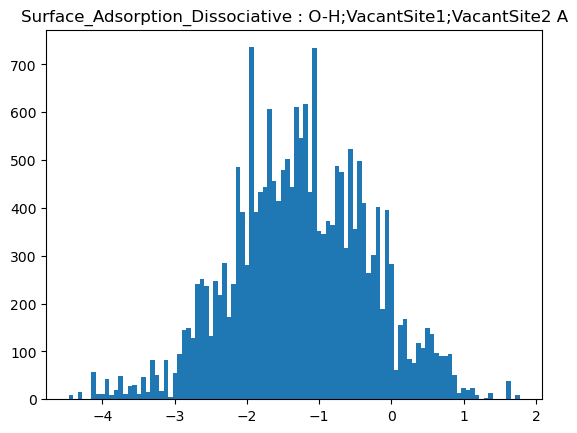

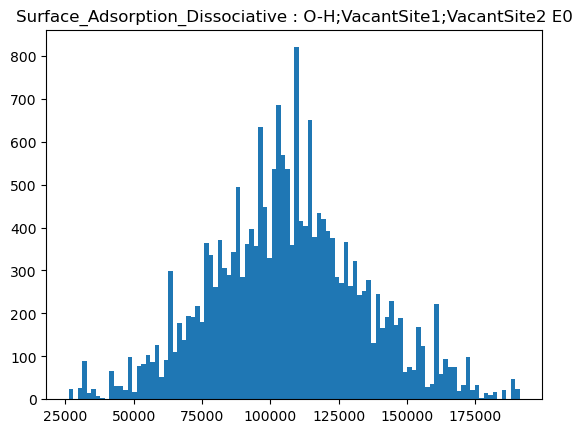

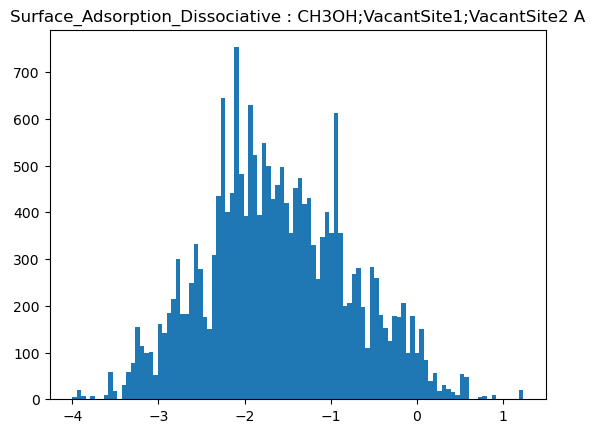

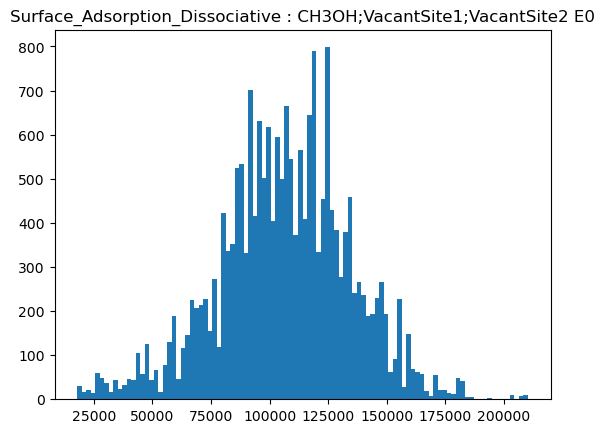

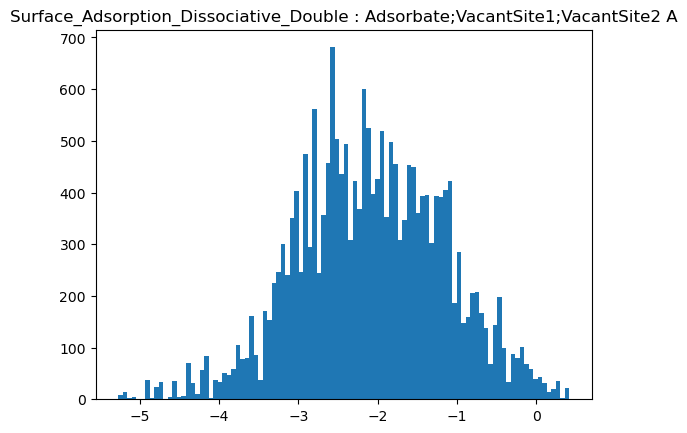

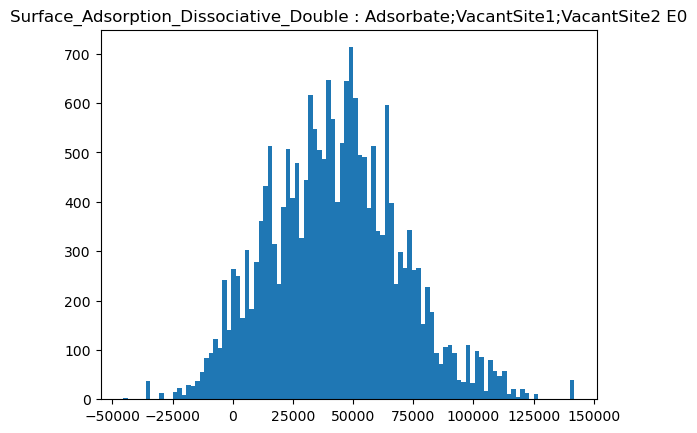

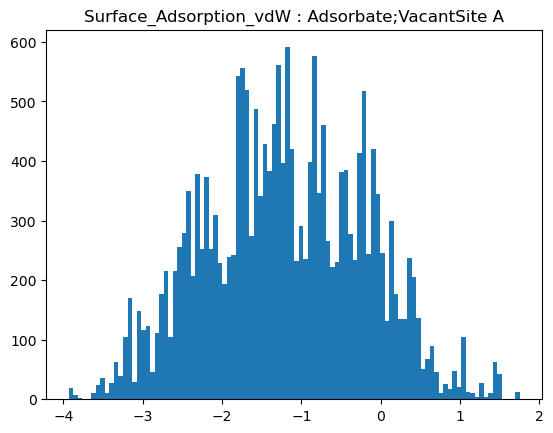

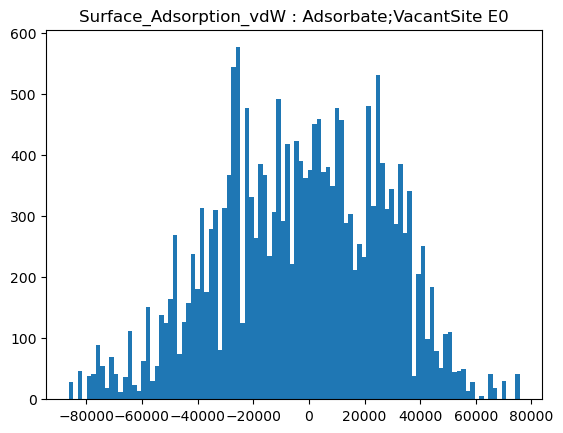

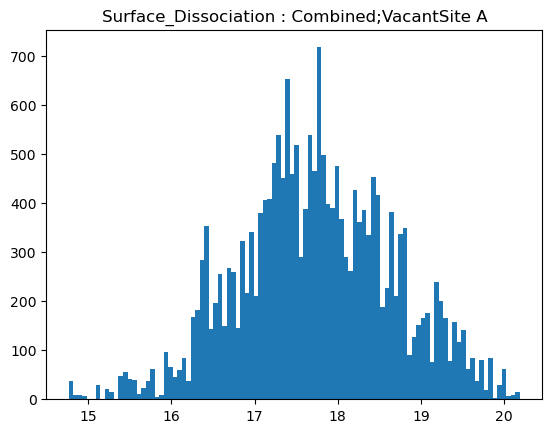

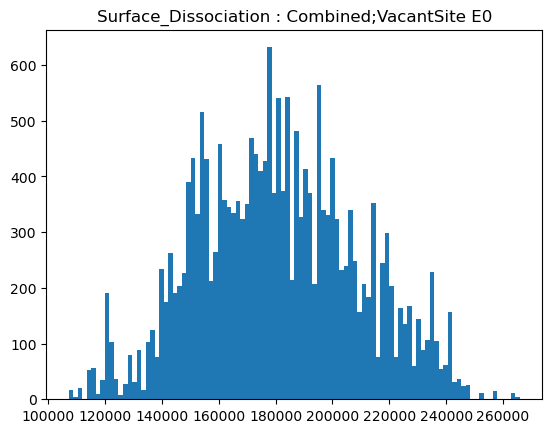

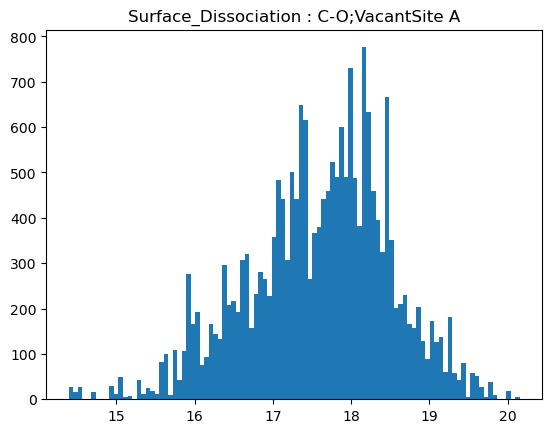

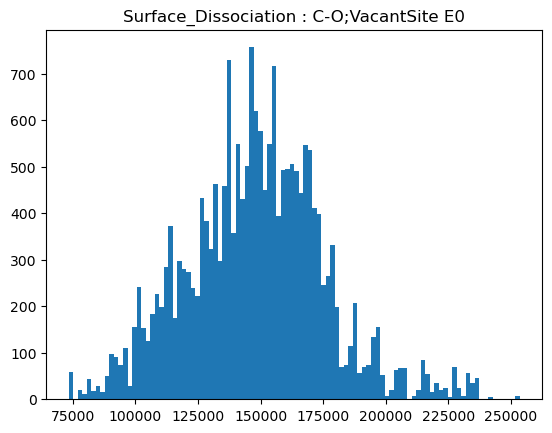

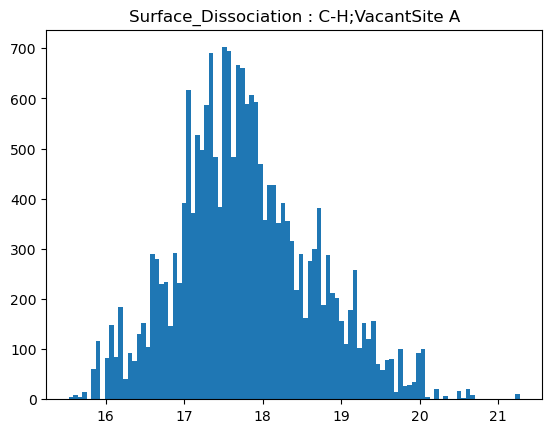

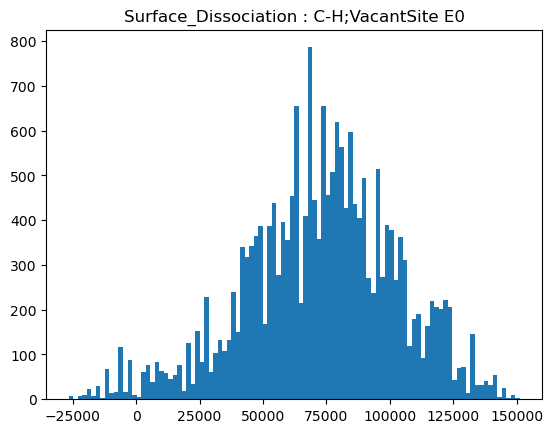

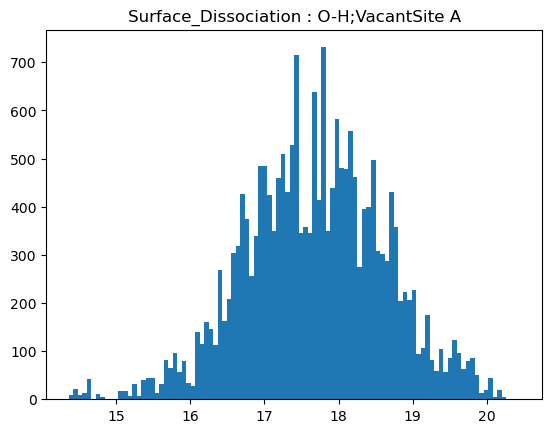

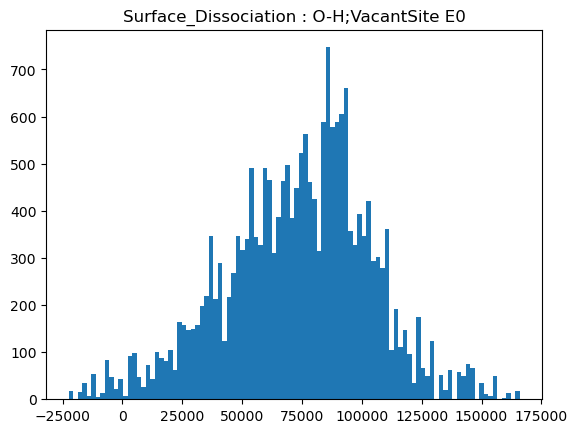

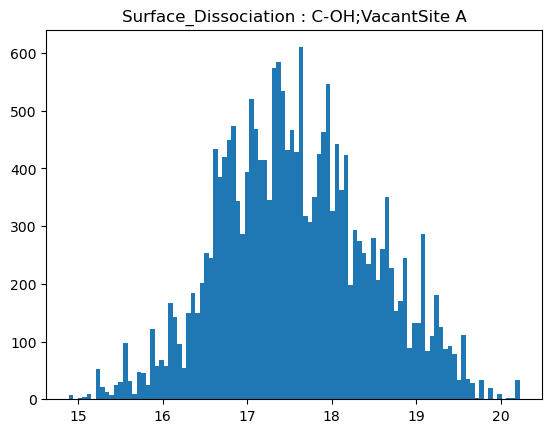

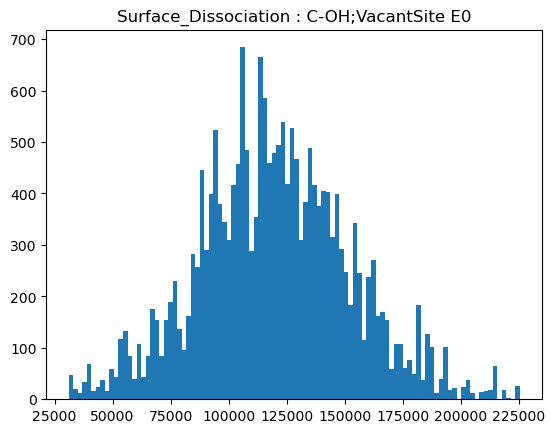

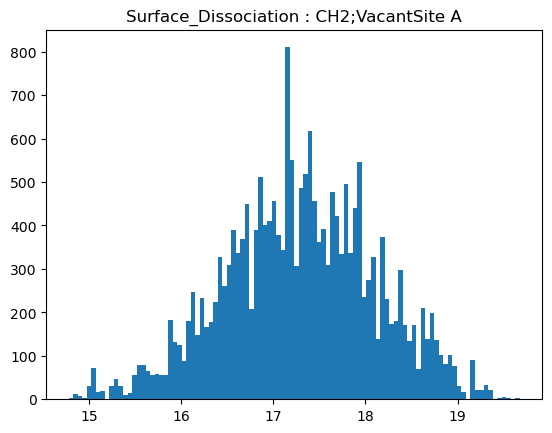

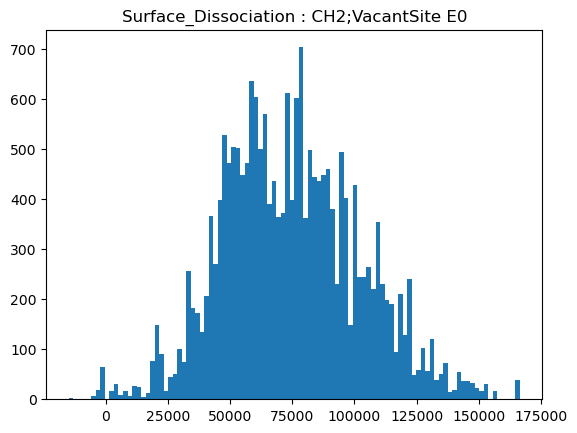

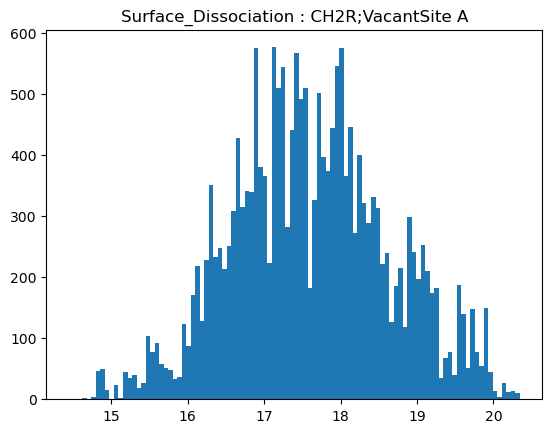

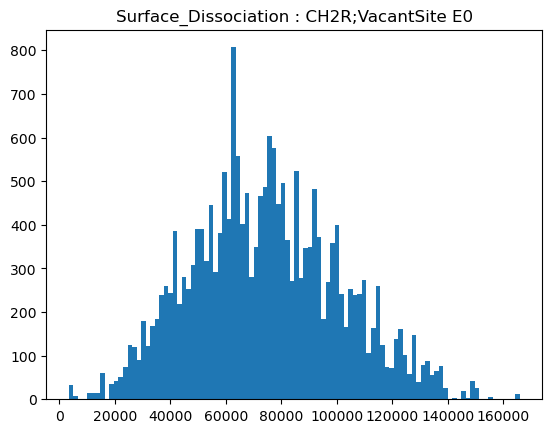

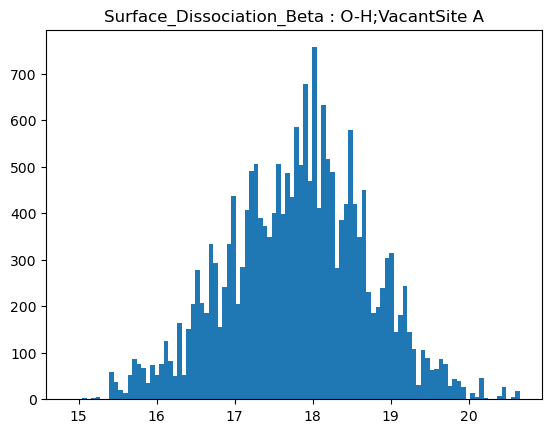

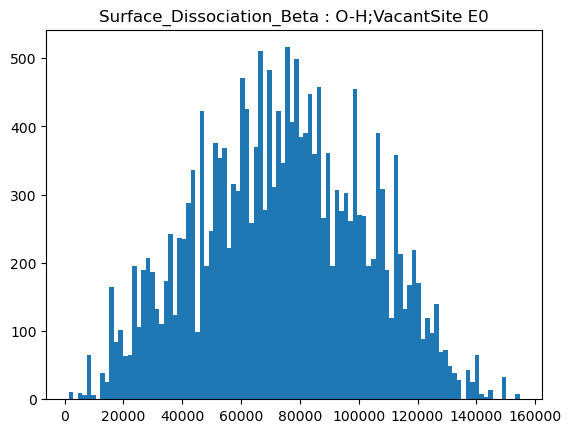

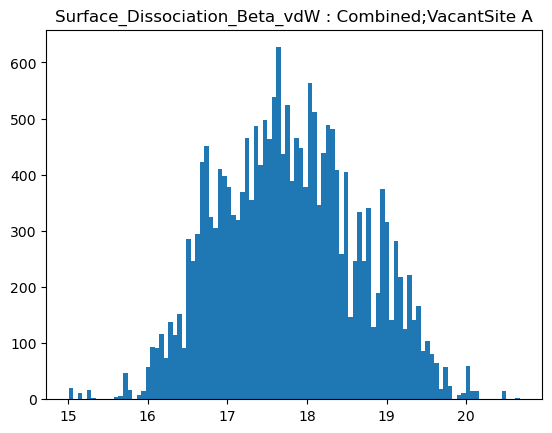

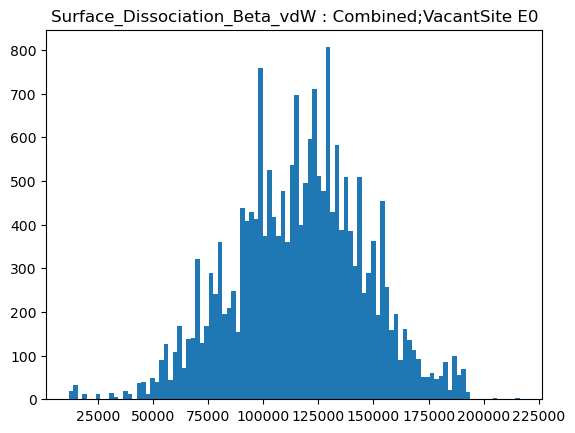

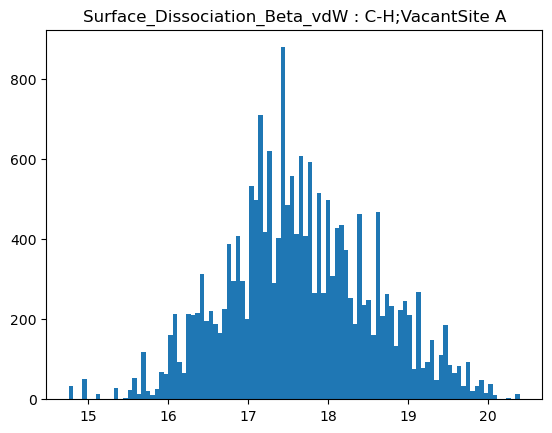

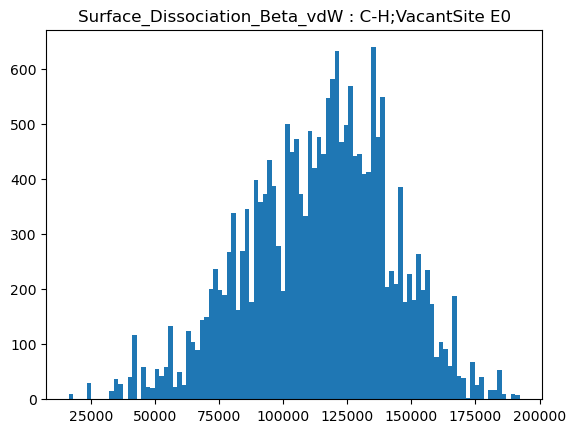

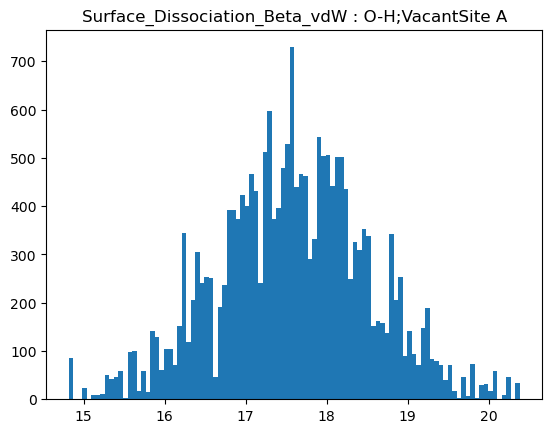

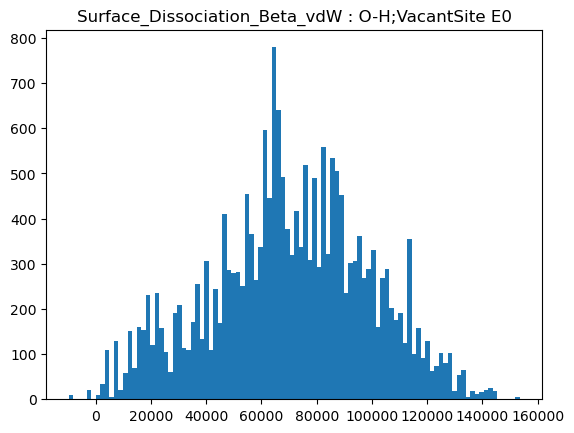

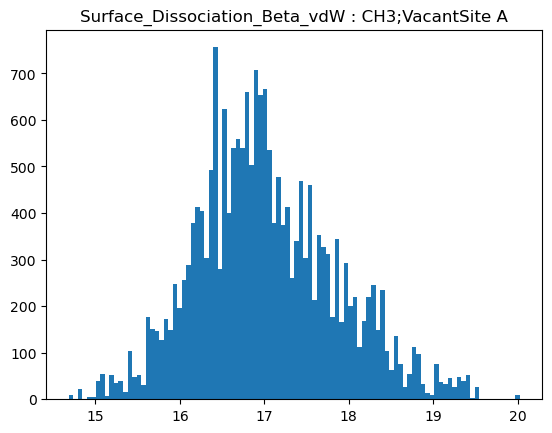

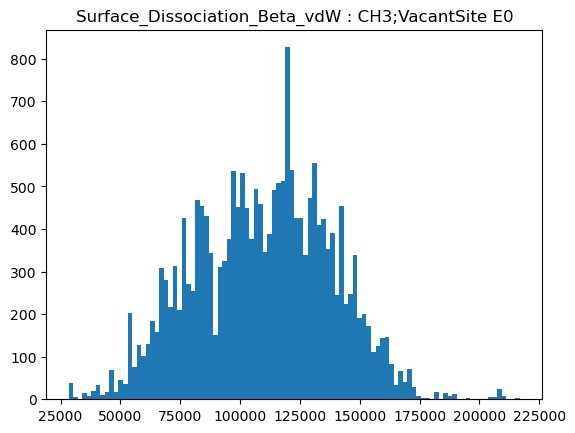

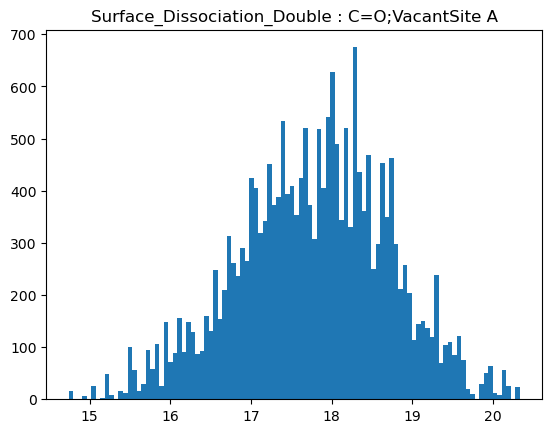

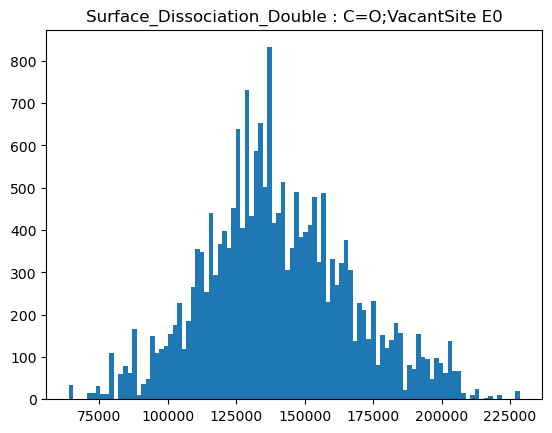

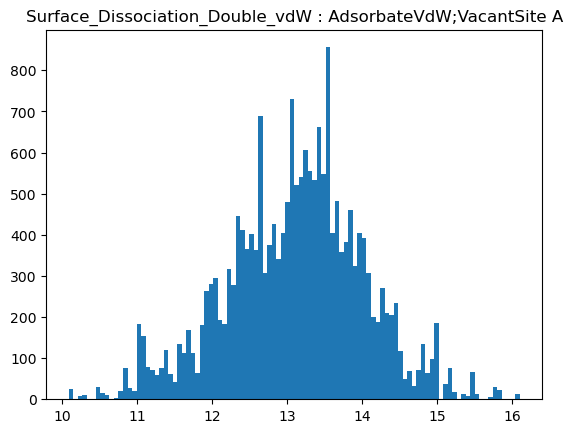

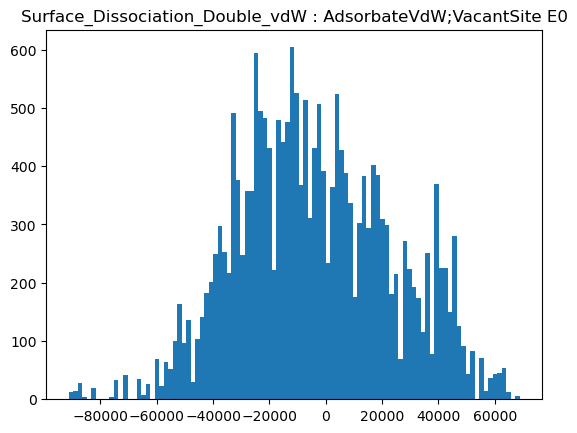

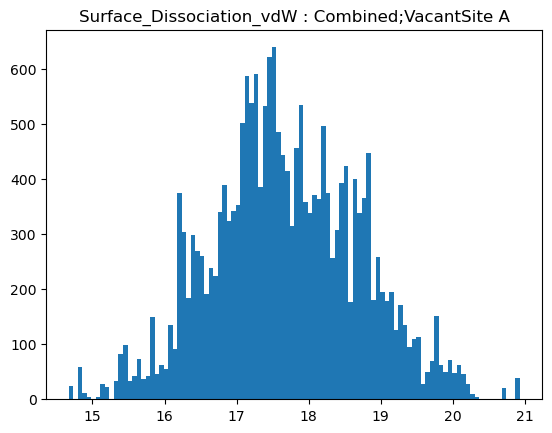

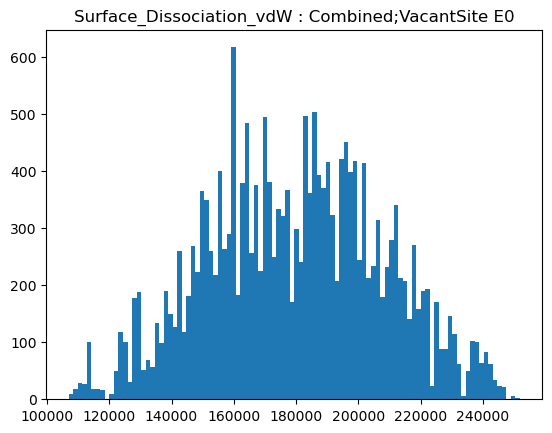

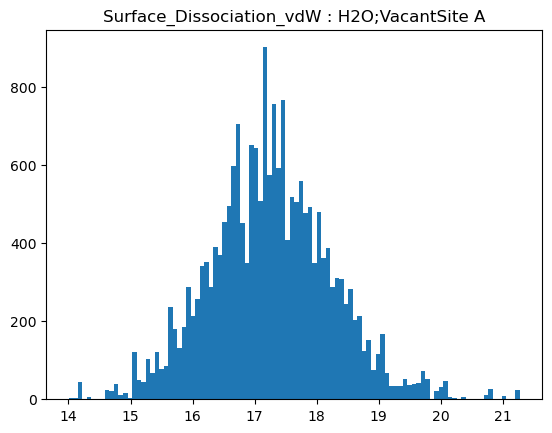

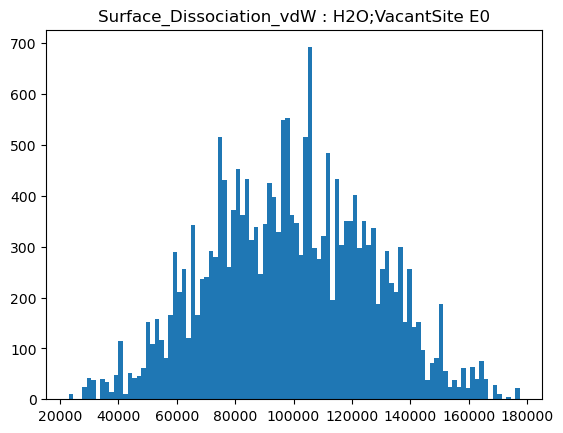

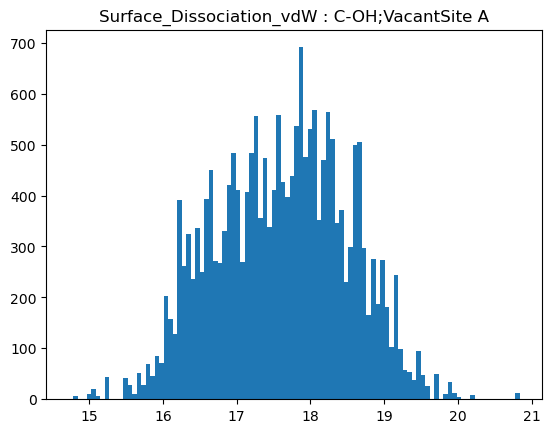

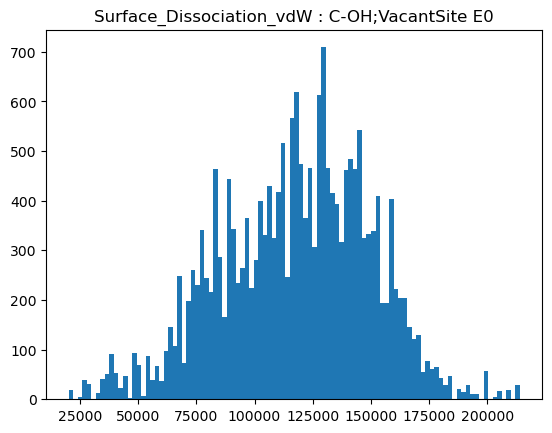

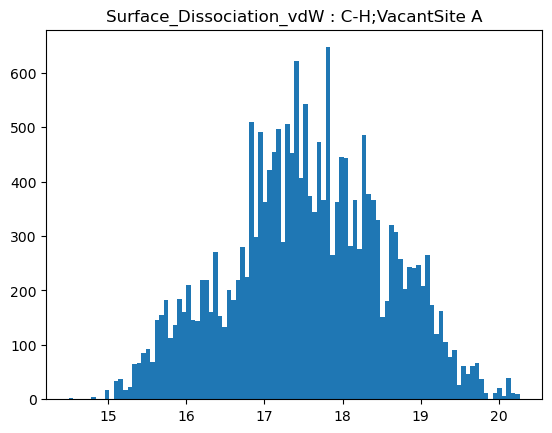

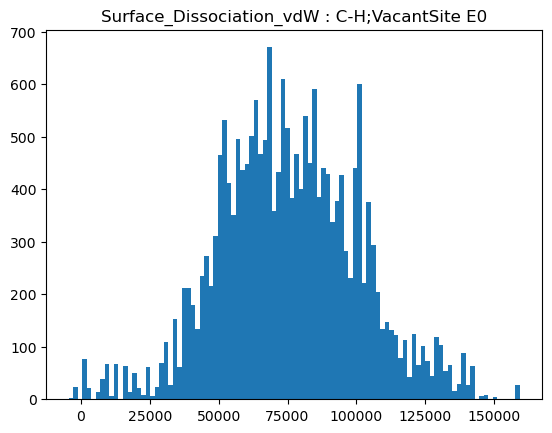

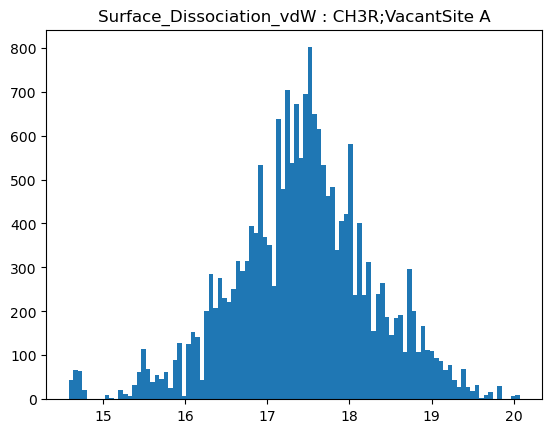

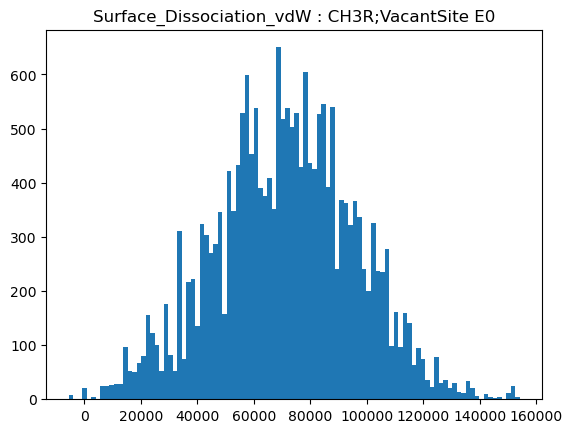

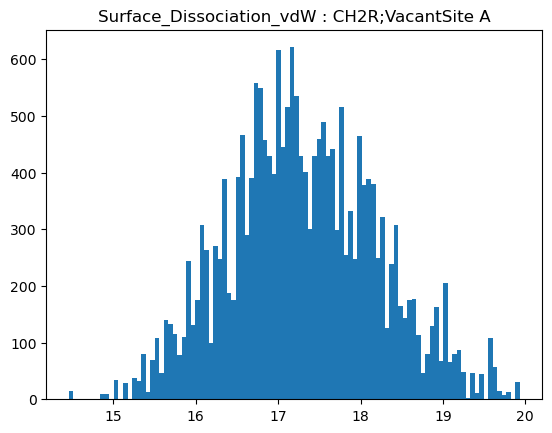

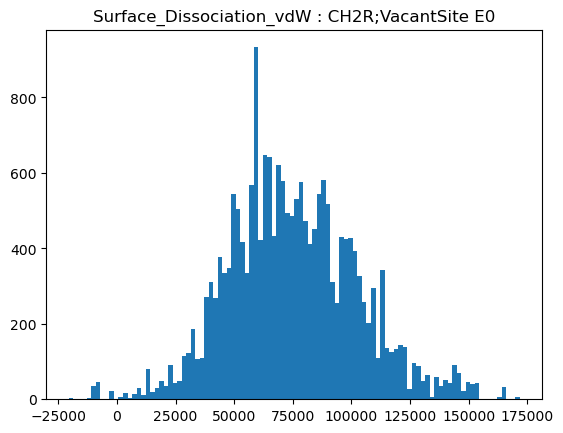

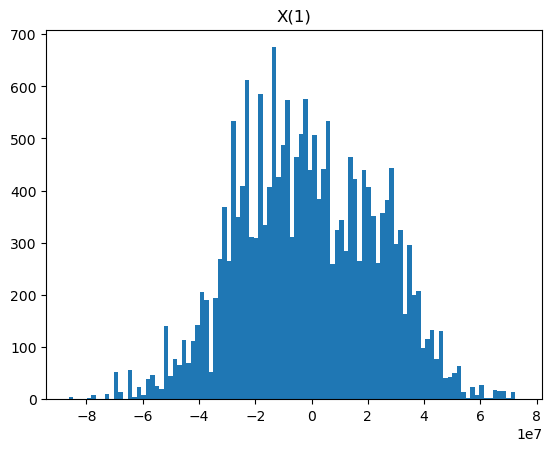

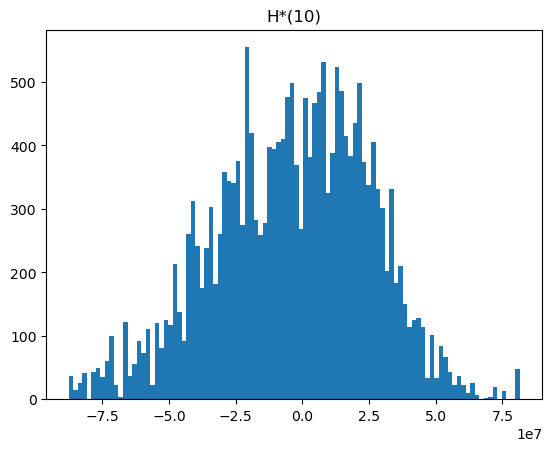

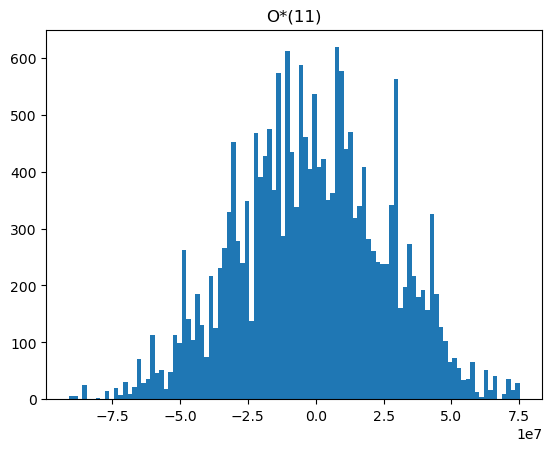

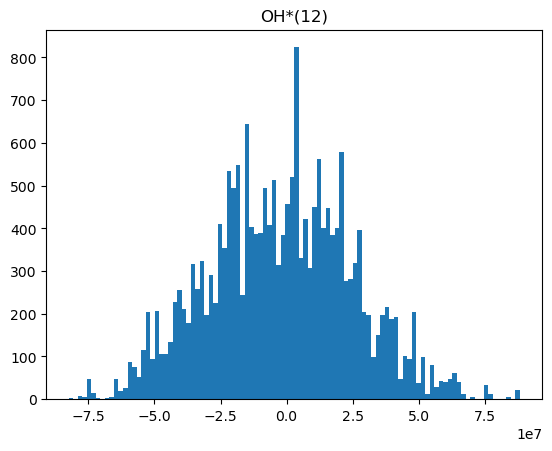

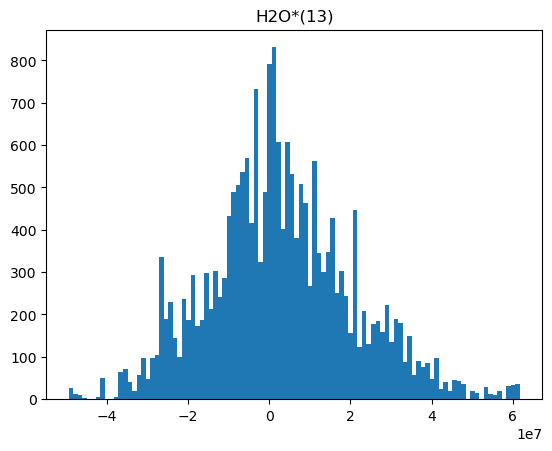

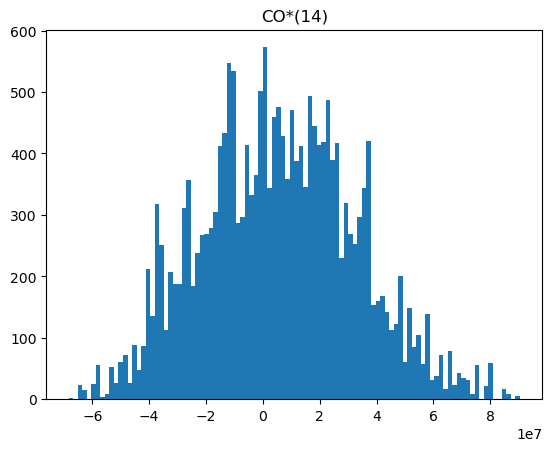

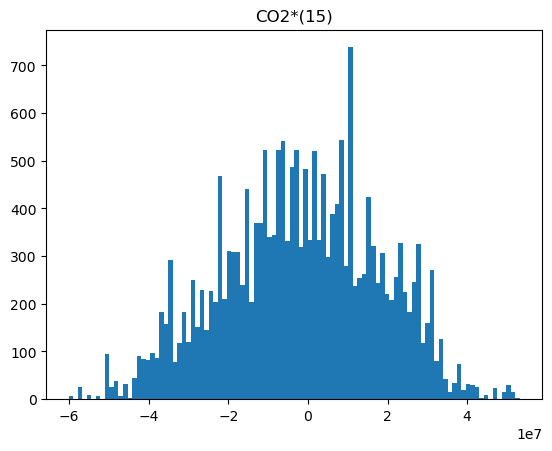

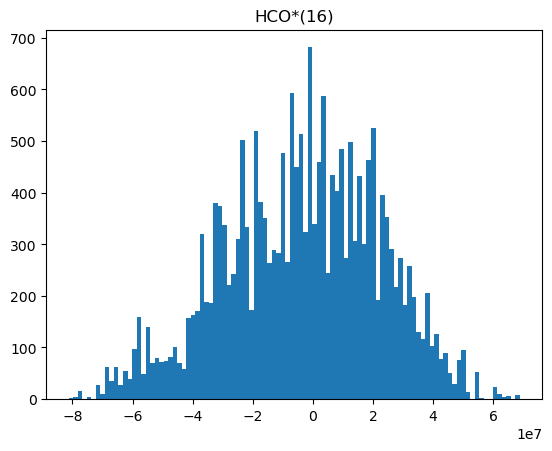

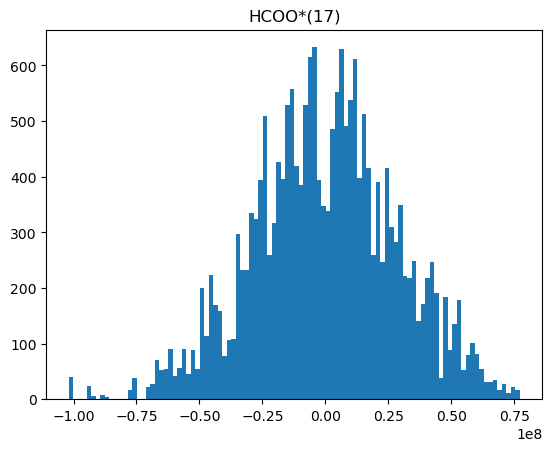

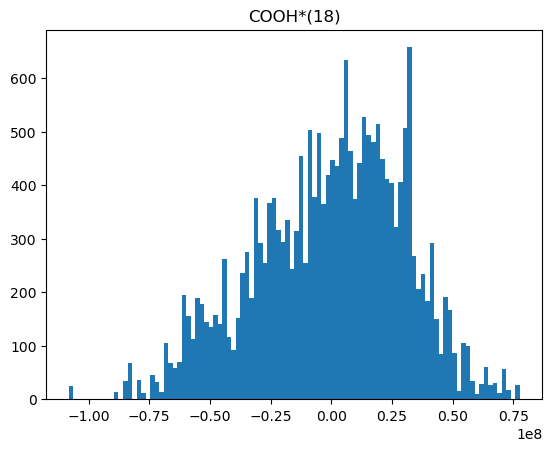

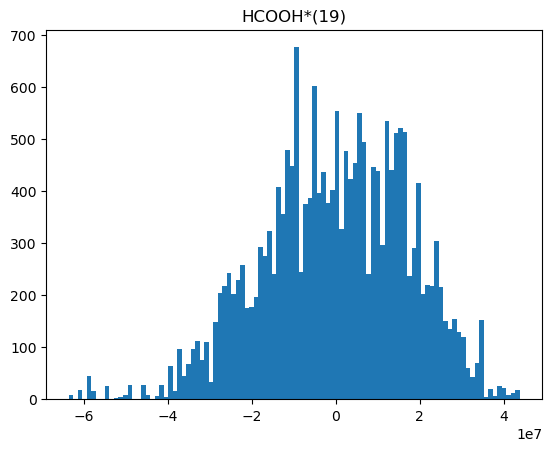

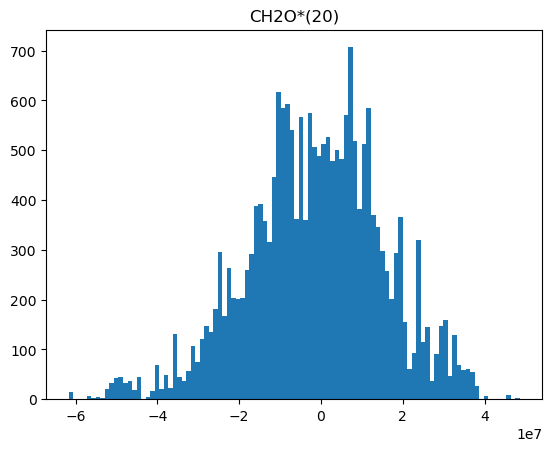

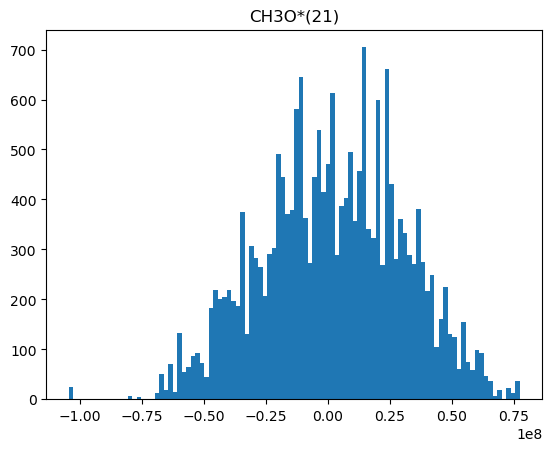

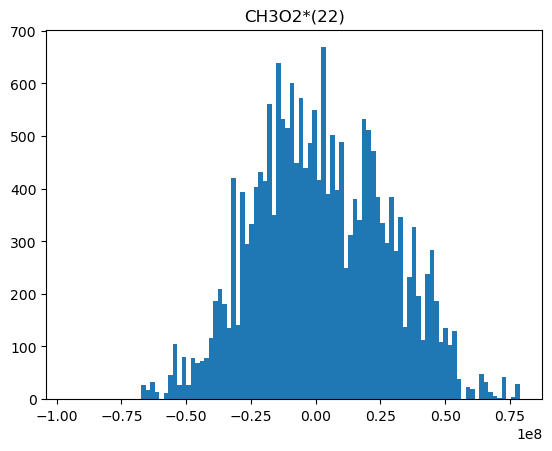

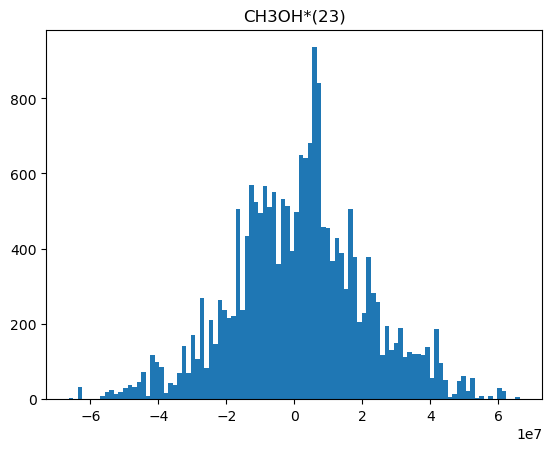

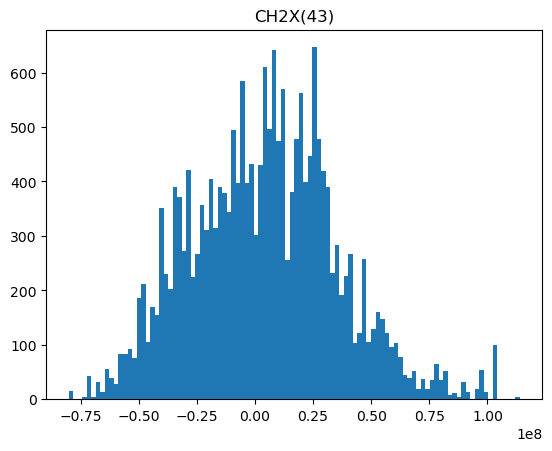

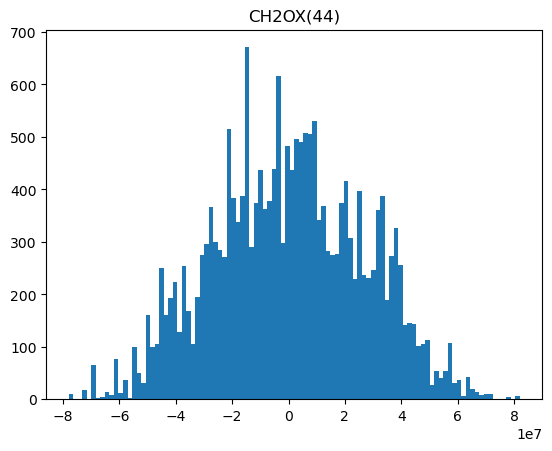

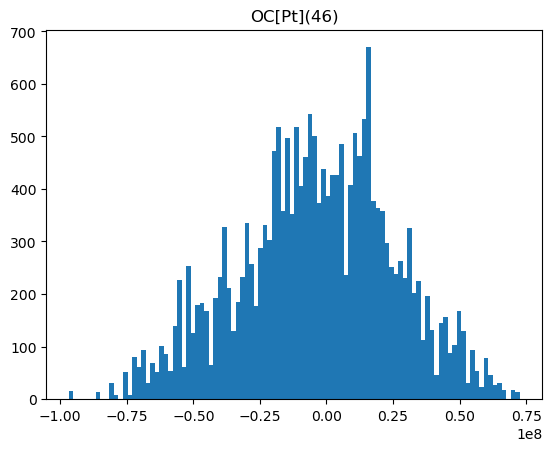

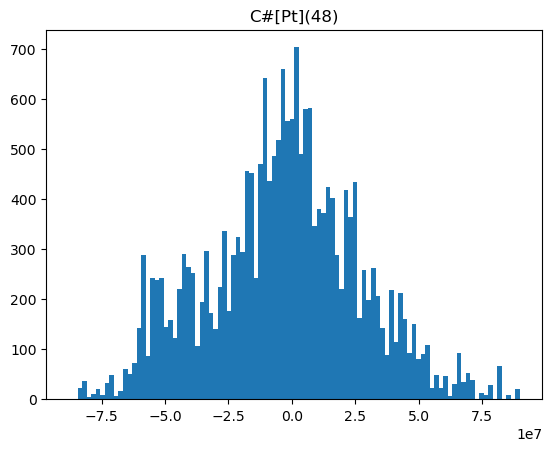

In [14]:
# pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/pe_object.dill"
pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/pe_object.dill"
# pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/pe_object.dill"
pic_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/pe_object.dill"
pe_object = PEUQSE.load_PE_object(pic_path)

# first, load the run with the highest logp:
param_values = pe_object.map_parameter_set
names = list(pe_object.UserInput.parameterNamesAndMathTypeExpressionsDict.keys())
for val in range(len(pe_object.post_burn_in_samples[0])):
    
    plt.clf()
    plt.title(names[val])
    plt.hist(pe_object.post_burn_in_samples[:,val], bins = 100)
    plt.show()

In [15]:
names = list(pe_object.UserInput.parameterNamesAndMathTypeExpressionsDict.keys())

In [16]:
for i in range(53):
    # open the gsa output pickle
    num = i+1
    print(f"processor {num}")
    gsa_path = f"/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/pickles/gsa_output_{num}.pkl"
    with open (gsa_path, "rb") as f: 
        gsa_dat = pickle.load(f)

    param_dat = list(zip(*gsa_dat))[1]
    print(len(param_dat))
    

processor 1
2
processor 2
2
processor 3
2
processor 4
2
processor 5
2
processor 6
2
processor 7
2
processor 8
2
processor 9
2
processor 10
2
processor 11
2
processor 12
2
processor 13
2
processor 14
2
processor 15
2
processor 16
2
processor 17
2
processor 18
2
processor 19
2
processor 20
2
processor 21
2
processor 22
2
processor 23
2
processor 24
2
processor 25
2
processor 26
2
processor 27
2
processor 28
2
processor 29
2
processor 30
2
processor 31
2
processor 32
2
processor 33
2
processor 34
2
processor 35
2
processor 36
2
processor 37
2
processor 38
2
processor 39
2
processor 40
2
processor 41
2
processor 42
2
processor 43
2
processor 44
2
processor 45
2
processor 46
2
processor 47
2
processor 48
2
processor 49
2
processor 50
2
processor 51
2
processor 52
2
processor 53
2


# 2. simulate the map parameter set

In [5]:
def remap_params(parameters, pe_obj, res_path): 
    """
    add the alphas back in to the parameter list
    """
    # load the config files so we only do that once: 
    rule_config_file = os.path.join(res_path, "rule_config.yaml")
    with open(rule_config_file, "r") as f:
        rule_dict_orig = yaml.safe_load(f)

    # load the be config file
    be_config_file = os.path.join(res_path, "be_guess.yaml")
    with open(be_config_file, "r") as f:
        be_config = yaml.safe_load(f)
        
        
    rule_dict_trim = dict(zip(pe_obj.UserInput.parameterNamesAndMathTypeExpressionsDict.keys(), parameters))
    full_dict = {}
    for rule, vals in rule_dict_orig.items():
        for key, val in vals.items(): 
            new_key = rule + " " + key
            full_dict[new_key] = val

    # update with binding energies
    full_dict.update(be_config)
    
    for key, value in rule_dict_trim.items(): 
        if key in full_dict.keys():
            full_dict[key] = value
        else:
            raise Exception(f"cannot find item: {key}")  
    
    return full_dict

## initial model

[c0403:26727] mca_base_component_repository_open: unable to open mca_btl_openib: libosmcomp.so.3: cannot open shared object file: No such file or directory (ignored)


Cantera version is too old for preconditioning, skipping...


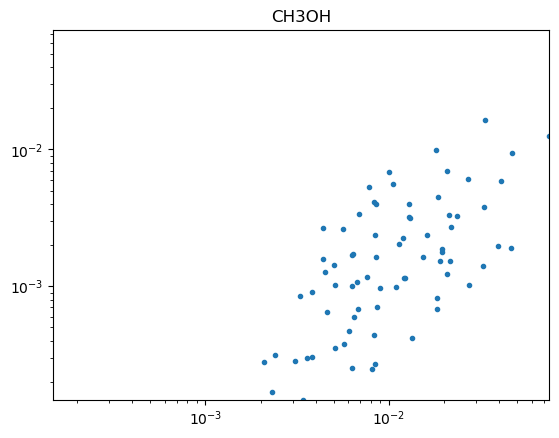

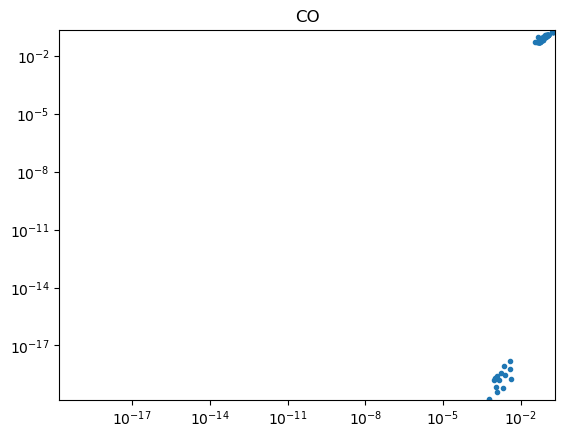

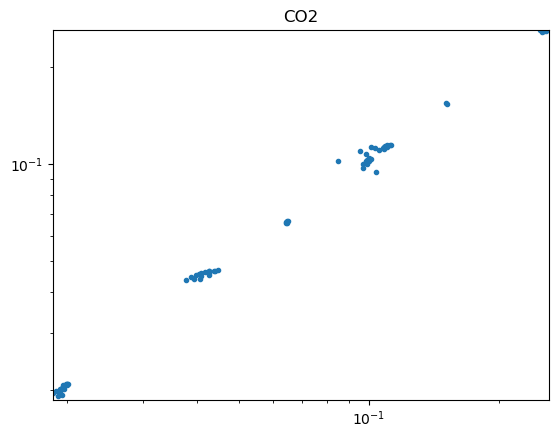

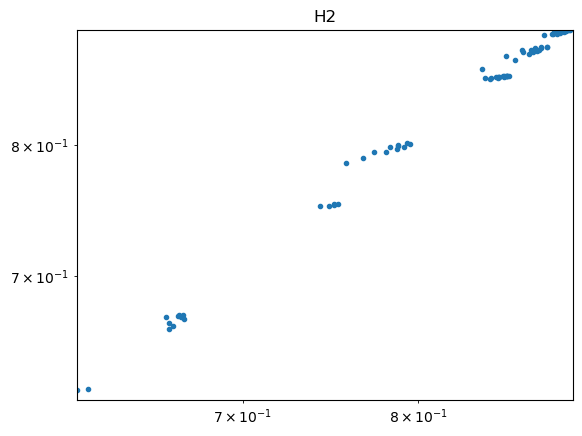

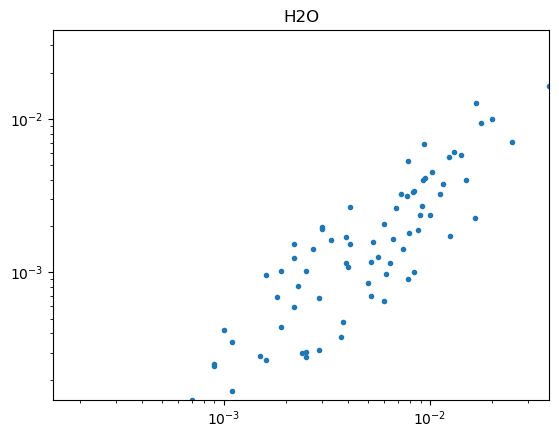

In [6]:
# check map run against graaf data
by_species=False
from cantera import CanteraError
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists

# load lookup dict
project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/"
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# generate settings array
settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
with open(settings_yaml, 'r') as f:
    settings = yaml.safe_load(f)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())



graaf_concs = {}
sim_concs = {}
specs = ['CH3OH','CO','CO2', 'H2', 'H2O',]

for spec in specs: 
    graaf_concs[spec] = []
    sim_concs[spec] = []
    

sbr = MinSBR(
    file_path,
    reac_config=settings[0],
    rtol=1.0e-11,
    atol=1.0e-22,
    reaction_list=starting_params['value_list'], 
    # reaction_list=new_param_values,
    results_path=results_path,
    use_precond=False, 
    time=2000,
    by_species=by_species
) 
for idx, setting in enumerate(settings): 
    sbr.reset_reactor(        
        reac_config=setting, 
        rtol=1.0e-11,
        atol=1.0e-22,
        )
    try:
        results = sbr.run_reactor_ss_memory(peuqse=True)
        
        for spec in specs:
            graaf_concs[spec].append(setting["species_out"][spec])
            sim_concs[spec].append(results[lookup_dict[spec]])
        
    except CanteraError as e: #CanteraError: making bare exception just to see if there is something catchable 
        print(f"could not solve system of equations with parameters {setting}, so setting outlet moles to nan")
        #don't append anything
        # for spec in specs:
        #     graaf_concs[spec].append(float('nan'))
        #     sim_concs[spec].append(float('nan'))
            
# parity plot for each species: 
for spec in specs: 
    plt.clf()
    plt.title(spec)
    plt.loglog(graaf_concs[spec], sim_concs[spec], ".")
    max_val = max(max(graaf_concs[spec]), max(sim_concs[spec]))
    min_val = min(min(graaf_concs[spec]), min(sim_concs[spec]))
    if min_val <=0:
        # min_val = max(min(graaf_concs[spec], min(sim_concs[spec])))
        min_val = 1e-15
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.show()

# correlated be's, optimize all output concentrations

Cantera version is too old for preconditioning, skipping...


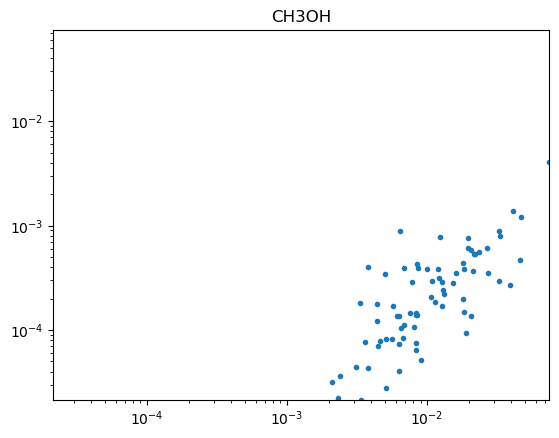

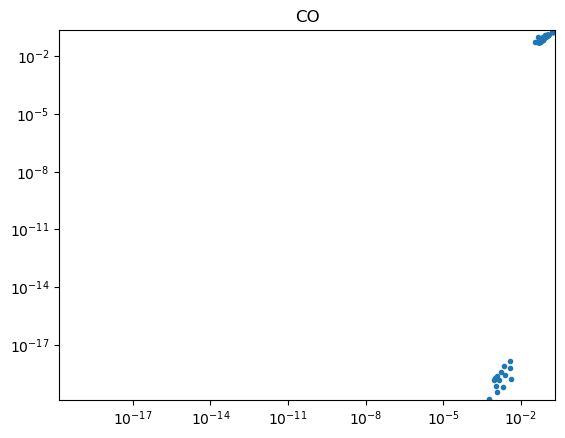

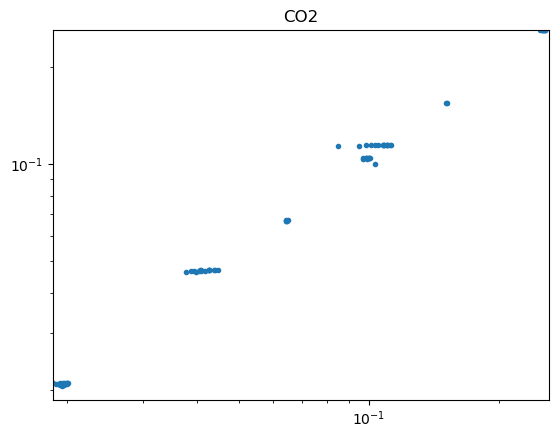

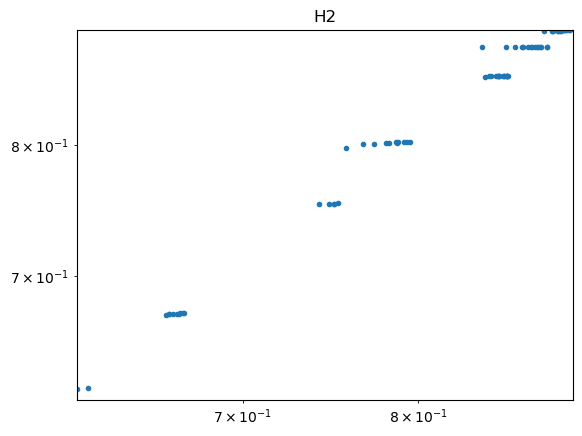

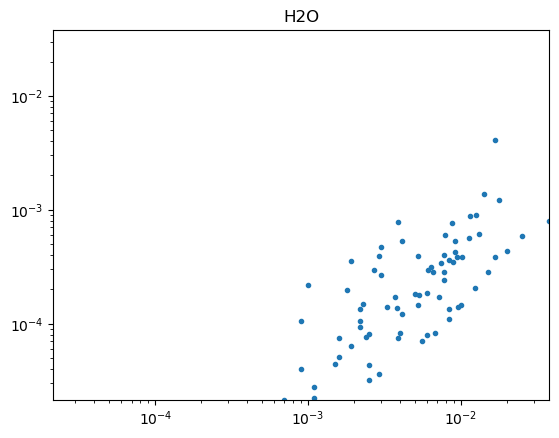

In [7]:
# check map run against graaf data
by_species=False
from cantera import CanteraError
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists

# load lookup dict
project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/"
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# generate settings array
settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
with open(settings_yaml, 'r') as f:
    settings = yaml.safe_load(f)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())



graaf_concs = {}
sim_concs = {}
specs = ['CH3OH','CO','CO2', 'H2', 'H2O',]

for spec in specs: 
    graaf_concs[spec] = []
    sim_concs[spec] = []
    

sbr = MinSBR(
    file_path,
    reac_config=settings[0],
    rtol=1.0e-11,
    atol=1.0e-22,
    # reaction_list=starting_params['value_list'], 
    reaction_list=new_param_values,
    results_path=results_path,
    use_precond=False, 
    time=2000,
    by_species=by_species
) 
for idx, setting in enumerate(settings): 
    sbr.reset_reactor(        
        reac_config=setting, 
        rtol=1.0e-11,
        atol=1.0e-22,
        )
    try:
        results = sbr.run_reactor_ss_memory(peuqse=True)
        
        for spec in specs:
            graaf_concs[spec].append(setting["species_out"][spec])
            sim_concs[spec].append(results[lookup_dict[spec]])
        
    except CanteraError as e: #CanteraError: making bare exception just to see if there is something catchable 
        print(f"could not solve system of equations with parameters {setting}, so setting outlet moles to nan")
        #don't append anything
        # for spec in specs:
        #     graaf_concs[spec].append(float('nan'))
        #     sim_concs[spec].append(float('nan'))
            
# parity plot for each species: 
for spec in specs: 
    plt.clf()
    plt.title(spec)
    plt.loglog(graaf_concs[spec], sim_concs[spec], ".")
    max_val = max(max(graaf_concs[spec]), max(sim_concs[spec]))
    min_val = min(min(graaf_concs[spec]), min(sim_concs[spec]))
    if min_val <=0:
        min_val = max(min(graaf_concs[spec], min(sim_concs[spec])))
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.show()

## MCMC search (asteroidal) with mcmc

Cantera version is too old for preconditioning, skipping...


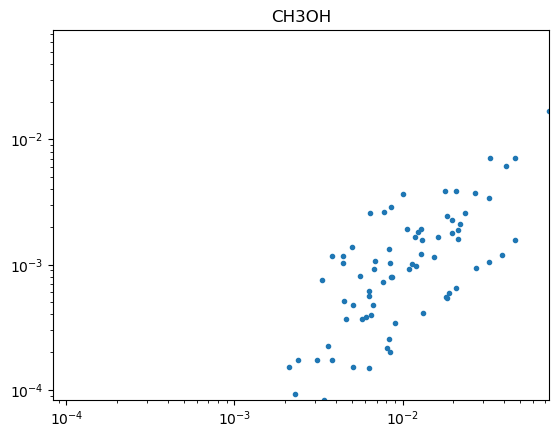

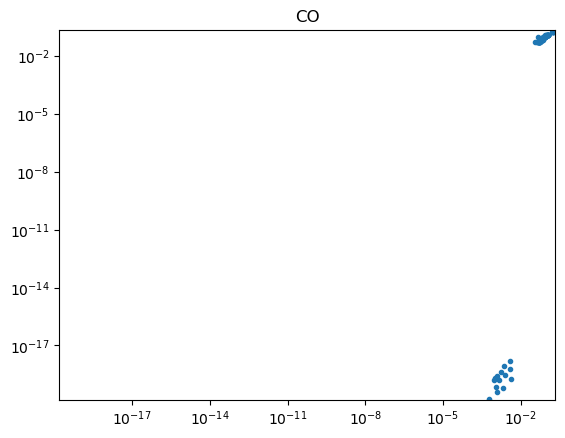

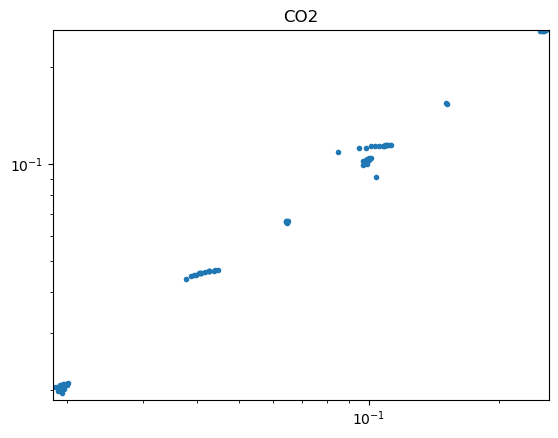

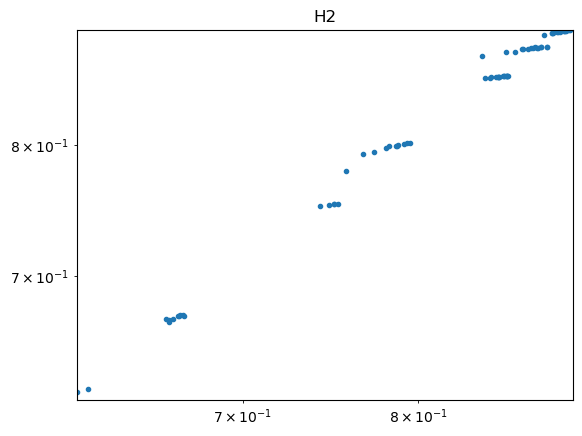

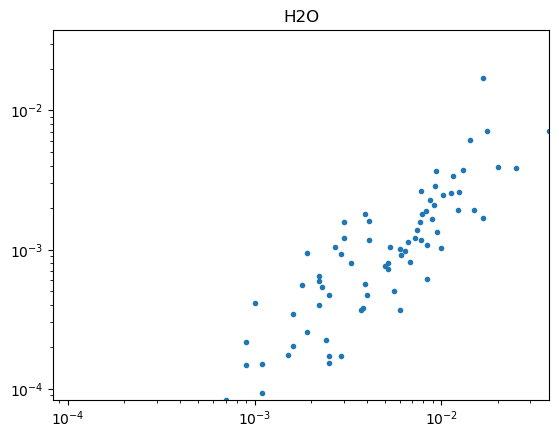

In [8]:
# check map run against graaf data
by_species=False
from cantera import CanteraError
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists

# load lookup dict
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/"
project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/"
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# generate settings array
settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
with open(settings_yaml, 'r') as f:
    settings = yaml.safe_load(f)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())



graaf_concs = {}
sim_concs = {}
specs = ['CH3OH','CO','CO2', 'H2', 'H2O',]

for spec in specs: 
    graaf_concs[spec] = []
    sim_concs[spec] = []
    

sbr = MinSBR(
    file_path,
    reac_config=settings[0],
    rtol=1.0e-11,
    atol=1.0e-22,
    # reaction_list=starting_params['value_list'], 
    reaction_list=new_param_values,
    results_path=results_path,
    use_precond=False, 
    time=2000,
    by_species=by_species
) 
for idx, setting in enumerate(settings): 
    sbr.reset_reactor(        
        reac_config=setting, 
        rtol=1.0e-11,
        atol=1.0e-22,
        )
    try:
        results = sbr.run_reactor_ss_memory(peuqse=True)
        
        for spec in specs:
            graaf_concs[spec].append(setting["species_out"][spec])
            sim_concs[spec].append(results[lookup_dict[spec]])
        
    except CanteraError as e: #CanteraError: making bare exception just to see if there is something catchable 
        print(f"could not solve system of equations with parameters {setting}, so setting outlet moles to nan")
        #don't append anything
        # for spec in specs:
        #     graaf_concs[spec].append(float('nan'))
        #     sim_concs[spec].append(float('nan'))
            
# parity plot for each species: 
for spec in specs: 
    plt.clf()
    plt.title(spec)
    plt.loglog(graaf_concs[spec], sim_concs[spec], ".")
    max_val = max(max(graaf_concs[spec]), max(sim_concs[spec]))
    min_val = min(min(graaf_concs[spec]), min(sim_concs[spec]))
    if min_val <=0:
        min_val = max(min(graaf_concs[spec], min(sim_concs[spec])))
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.show()

## simple mcmc with only ch3oh and H2O used in log p calc

Cantera version is too old for preconditioning, skipping...


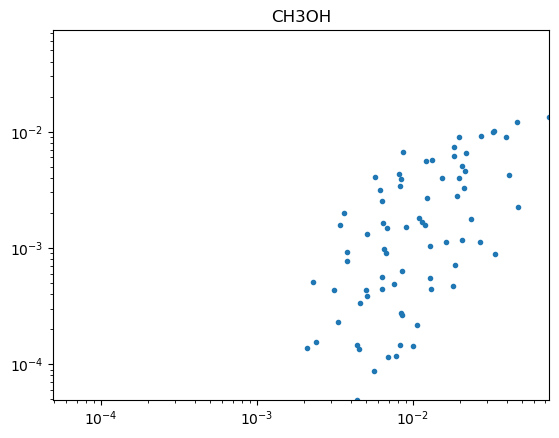

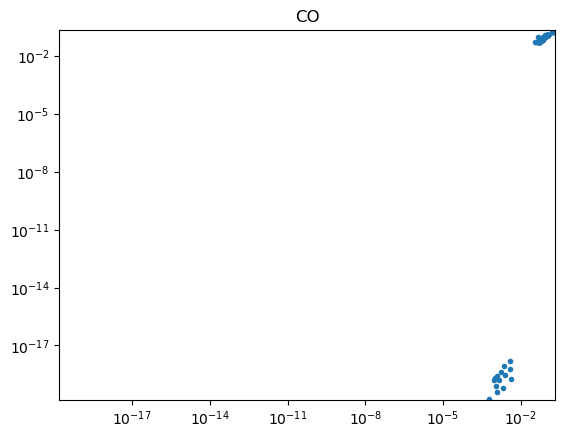

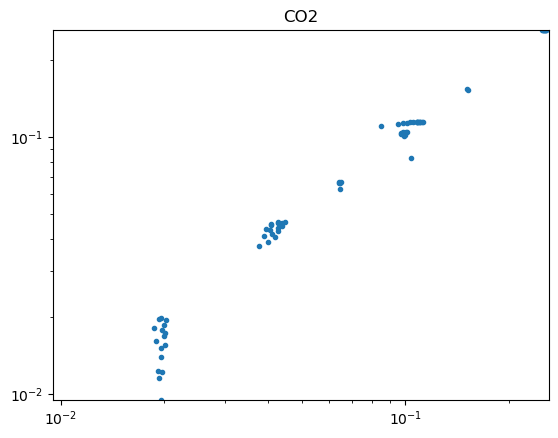

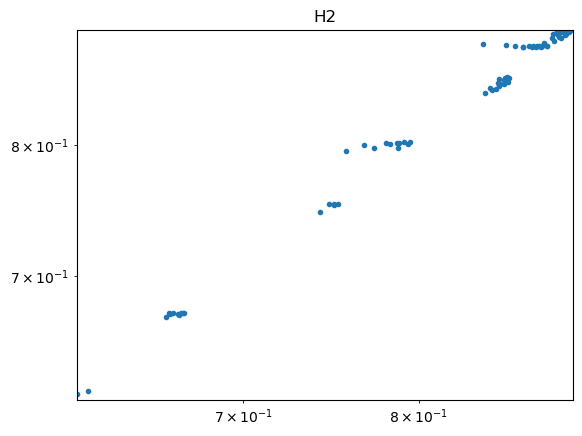

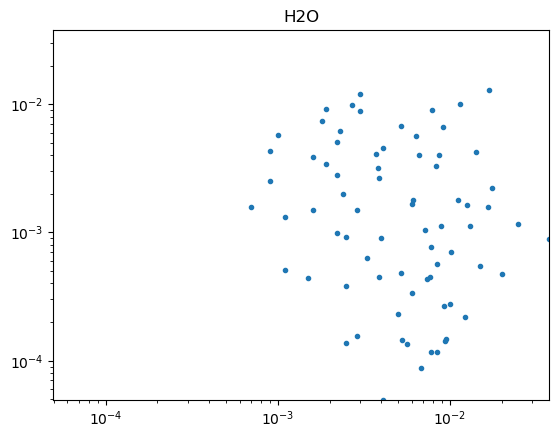

In [9]:
# check map run against graaf data
by_species=False
from cantera import CanteraError
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists

# load lookup dict
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/"
project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# generate settings array
settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
with open(settings_yaml, 'r') as f:
    settings = yaml.safe_load(f)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())



graaf_concs = {}
sim_concs = {}
specs = ['CH3OH','CO','CO2', 'H2', 'H2O',]

for spec in specs: 
    graaf_concs[spec] = []
    sim_concs[spec] = []
    

sbr = MinSBR(
    file_path,
    reac_config=settings[0],
    rtol=1.0e-11,
    atol=1.0e-22,
    # reaction_list=starting_params['value_list'], 
    reaction_list=new_param_values,
    results_path=results_path,
    use_precond=False, 
    time=2000,
    by_species=by_species
) 
for idx, setting in enumerate(settings): 
    sbr.reset_reactor(        
        reac_config=setting, 
        rtol=1.0e-11,
        atol=1.0e-22,
        )
    try:
        results = sbr.run_reactor_ss_memory(peuqse=True)
        
        for spec in specs:
            graaf_concs[spec].append(setting["species_out"][spec])
            sim_concs[spec].append(results[lookup_dict[spec]])
        
    except CanteraError as e: #CanteraError: making bare exception just to see if there is something catchable 
        print(f"could not solve system of equations with parameters {setting}, so setting outlet moles to nan")
        #don't append anything
        # for spec in specs:
        #     graaf_concs[spec].append(float('nan'))
        #     sim_concs[spec].append(float('nan'))
            
# parity plot for each species: 
for spec in specs: 
    plt.clf()
    plt.title(spec)
    plt.loglog(graaf_concs[spec], sim_concs[spec], ".")
    max_val = max(max(graaf_concs[spec]), max(sim_concs[spec]))
    min_val = min(min(graaf_concs[spec]), min(sim_concs[spec]))
    if min_val <=0:
        min_val = max(min(graaf_concs[spec], min(sim_concs[spec])))
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.show()

## perturb each species individually instead of by atomic BE, using only H2o and ch3OH in log p, 

Cantera version is too old for preconditioning, skipping...


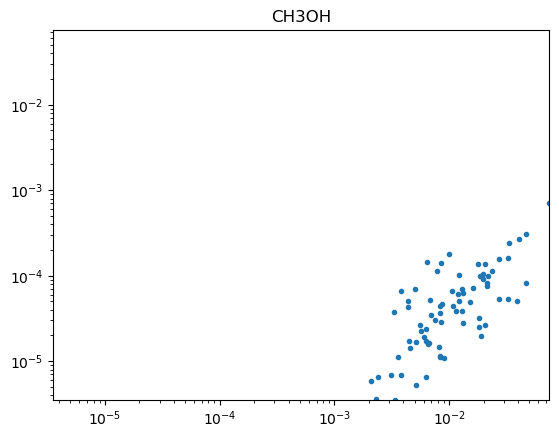

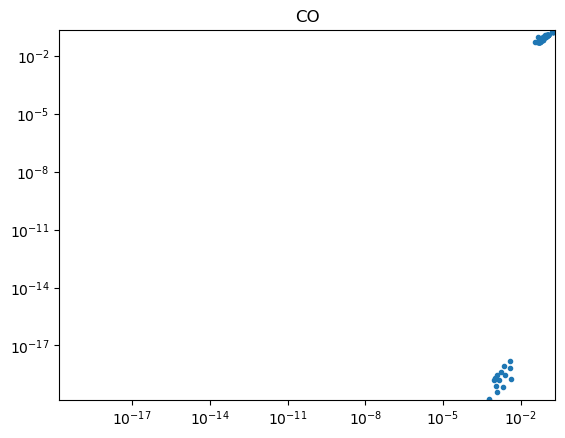

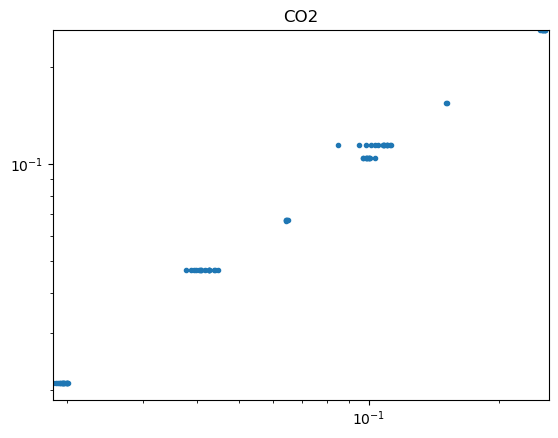

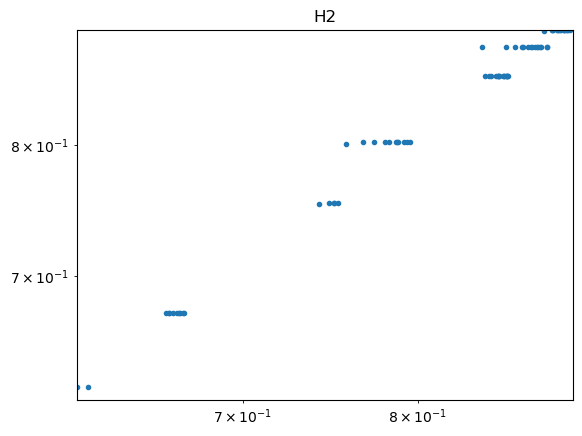

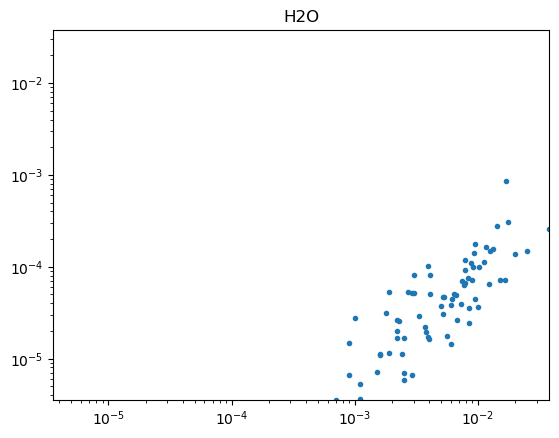

In [10]:
# check map run against graaf data
by_species=True
from cantera import CanteraError
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists

# load lookup dict
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/"
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/"
project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# generate settings array
settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
with open(settings_yaml, 'r') as f:
    settings = yaml.safe_load(f)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())



graaf_concs = {}
sim_concs = {}
specs = ['CH3OH','CO','CO2', 'H2', 'H2O',]

for spec in specs: 
    graaf_concs[spec] = []
    sim_concs[spec] = []
    

sbr = MinSBR(
    file_path,
    reac_config=settings[0],
    rtol=1.0e-11,
    atol=1.0e-22,
    # reaction_list=starting_params['value_list'], 
    reaction_list=new_param_values,
    results_path=results_path,
    use_precond=False, 
    time=2000,
    by_species=by_species
) 
for idx, setting in enumerate(settings): 
    sbr.reset_reactor(        
        reac_config=setting, 
        rtol=1.0e-11,
        atol=1.0e-22,
        )
    try:
        results = sbr.run_reactor_ss_memory(peuqse=True)
        
        for spec in specs:
            graaf_concs[spec].append(setting["species_out"][spec])
            sim_concs[spec].append(results[lookup_dict[spec]])
        
    except CanteraError as e: #CanteraError: making bare exception just to see if there is something catchable 
        print(f"could not solve system of equations with parameters {setting}, so setting outlet moles to nan")
        #don't append anything
        # for spec in specs:
        #     graaf_concs[spec].append(float('nan'))
        #     sim_concs[spec].append(float('nan'))
            
# parity plot for each species: 
for spec in specs: 
    plt.clf()
    plt.title(spec)
    plt.loglog(graaf_concs[spec], sim_concs[spec], ".")
    max_val = max(max(graaf_concs[spec]), max(sim_concs[spec]))
    min_val = min(min(graaf_concs[spec]), min(sim_concs[spec]))
    if min_val <=0:
        min_val = max(min(graaf_concs[spec], min(sim_concs[spec])))
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.show()

Cantera version is too old for preconditioning, skipping...


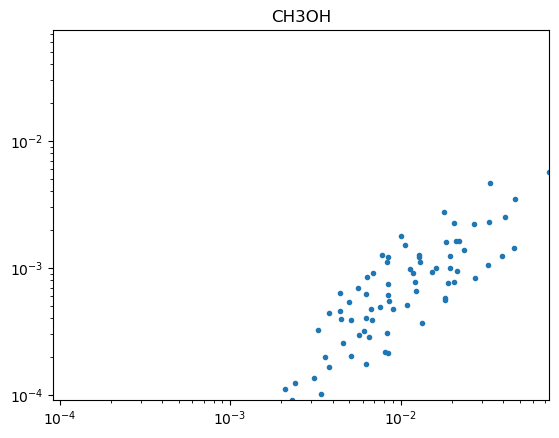

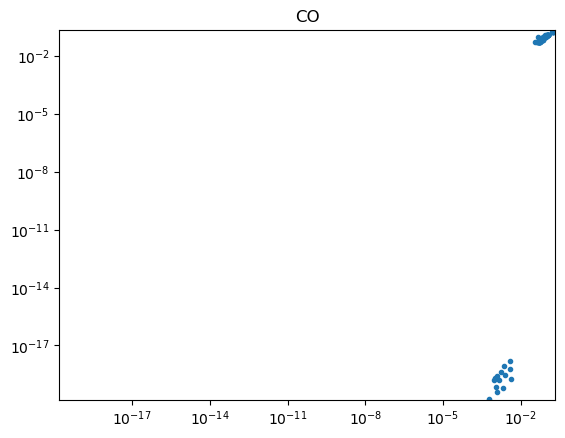

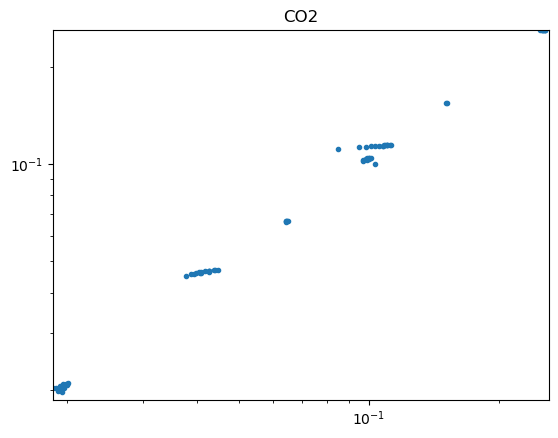

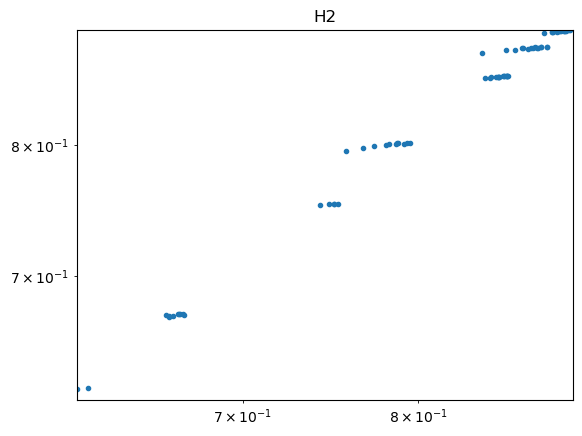

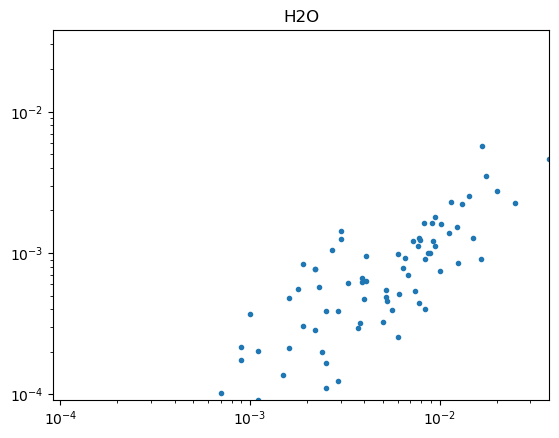

In [11]:
# check map run against graaf data
by_species=True
from cantera import CanteraError
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists

# load lookup dict
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/"
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"
project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_10Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# generate settings array
settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
with open(settings_yaml, 'r') as f:
    settings = yaml.safe_load(f)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())



graaf_concs = {}
sim_concs = {}
specs = ['CH3OH','CO','CO2', 'H2', 'H2O',]

for spec in specs: 
    graaf_concs[spec] = []
    sim_concs[spec] = []
    

sbr = MinSBR(
    file_path,
    reac_config=settings[0],
    rtol=1.0e-11,
    atol=1.0e-22,
    # reaction_list=starting_params['value_list'], 
    reaction_list=new_param_values,
    results_path=results_path,
    use_precond=False, 
    time=2000,
    by_species=by_species
) 
for idx, setting in enumerate(settings): 
    sbr.reset_reactor(        
        reac_config=setting, 
        rtol=1.0e-11,
        atol=1.0e-22,
        )
    try:
        results = sbr.run_reactor_ss_memory(peuqse=True)
        
        for spec in specs:
            graaf_concs[spec].append(setting["species_out"][spec])
            sim_concs[spec].append(results[lookup_dict[spec]])
        
    except CanteraError as e: #CanteraError: making bare exception just to see if there is something catchable 
        print(f"could not solve system of equations with parameters {setting}, so setting outlet moles to nan")
        #don't append anything
        # for spec in specs:
        #     graaf_concs[spec].append(float('nan'))
        #     sim_concs[spec].append(float('nan'))
            
# parity plot for each species: 
for spec in specs: 
    plt.clf()
    plt.title(spec)
    plt.loglog(graaf_concs[spec], sim_concs[spec], ".")
    max_val = max(max(graaf_concs[spec]), max(sim_concs[spec]))
    min_val = min(min(graaf_concs[spec]), min(sim_concs[spec]))
    if min_val <=0:
        min_val = max(min(graaf_concs[spec], min(sim_concs[spec])))
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.show()

# test if we get the same answer after running the reactor multiple times

In [1]:
import pickle
import os
import yaml
import sys
import PEUQSE
repo_dir = '/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis'
if repo_dir not in sys.path:
    sys.path.append(repo_dir)

In [2]:
def remap_params(parameters, pe_obj, res_path): 
    """
    add the alphas back in to the parameter list
    """
    # load the config files so we only do that once: 
    rule_config_file = os.path.join(res_path, "rule_config.yaml")
    with open(rule_config_file, "r") as f:
        rule_dict_orig = yaml.safe_load(f)

    # load the be config file
    be_config_file = os.path.join(res_path, "be_guess.yaml")
    with open(be_config_file, "r") as f:
        be_config = yaml.safe_load(f)
        
        
    rule_dict_trim = dict(zip(pe_obj.UserInput.parameterNamesAndMathTypeExpressionsDict.keys(), parameters))
    full_dict = {}
    for rule, vals in rule_dict_orig.items():
        for key, val in vals.items(): 
            new_key = rule + " " + key
            full_dict[new_key] = val

    # update with binding energies
    full_dict.update(be_config)
    
    for key, value in rule_dict_trim.items(): 
        if key in full_dict.keys():
            full_dict[key] = value
        else:
            raise Exception(f"cannot find item: {key}")  
    
    return full_dict

# test if the answer is the same when we reset the minsbr objects each time

In [6]:
# check map run against graaf data
by_species=True
from cantera import CanteraError
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists
from rmg_gua.gua_peuqse import ct_simulation_2

# load lookup dict
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_19jul/"
# project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_search_22Jul/"
# project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_31_jul/"
project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# generate settings array
settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
with open(settings_yaml, 'r') as f:
    settings = yaml.safe_load(f)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())



specs = ['CH3OH', 'H2O']

ct_simulation_2.sim_init(
    project_path, 
    output_species = specs, 
    thermo_by_species=True, 
    reset_reac=
)
results1 = ct_simulation_2.simulation_function_wrapper(new_param_values)

Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for precondit

In [17]:
results1

array([[2.76665835e-05, 4.82666074e-06, 1.63172495e-05, 2.97583316e-06,
        1.01939621e-05, 2.59008324e-05, 5.57290268e-05, 4.90453018e-06,
        4.24040962e-05, 1.26473855e-05, 2.15160439e-05, 1.12066645e-05],
       [5.38531076e-05, 7.19344139e-06, 2.54346271e-05, 3.85325348e-06,
        1.17254716e-05, 2.87864968e-05, 7.65316862e-05, 5.33684635e-06,
        5.43781250e-05, 1.42836865e-05, 2.34354293e-05, 1.14050476e-05]])

In [7]:
results2 = ct_simulation_2.simulation_function_wrapper(new_param_values)

Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
start time: Mon Aug 12 12:38:50 2024
end time: Mon Aug 12 12:39:00 2024
elapsed: 10.141654014587402 seconds


In [8]:
results1 == results2

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True]])

# test if our answers are the same if we run reactor without the reset reac

In [9]:
ct_simulation_2.sim_init(
    project_path, 
    output_species = specs, 
    thermo_by_species=True, 
    reset_reac=False
)
results1b = ct_simulation_2.simulation_function_wrapper(new_param_values)
results2b = ct_simulation_2.simulation_function_wrapper(new_param_values)

Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
start time: Mon Aug 12 12:39:57 2024
end time: Mon Aug 12 12:40:03 2024
elapsed: 5.440293073654175 seconds
start time: Mon Aug 12 12:40:03 2024
end time: Mon Aug 12 12:40:08 2024
elapsed: 5.441517353057861 seconds


In [10]:
results1b == results2b

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True]])

In [11]:
results1 == results1b

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True]])

# test if running one set of parameters, then another, changes answer, or if we get the same answer each time

In [14]:
results1c = ct_simulation_2.simulation_function_wrapper(starting_params['value_list'])
results2c = ct_simulation_2.simulation_function_wrapper(new_param_values)
results3c = ct_simulation_2.simulation_function_wrapper(starting_params['value_list'])

start time: Mon Aug 12 13:05:48 2024
end time: Mon Aug 12 13:05:55 2024
elapsed: 6.3591697216033936 seconds
start time: Mon Aug 12 13:05:55 2024
end time: Mon Aug 12 13:06:00 2024
elapsed: 5.444547176361084 seconds
start time: Mon Aug 12 13:06:00 2024
end time: Mon Aug 12 13:06:07 2024
elapsed: 6.578839063644409 seconds


In [13]:
results2c == results1

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True]])

In [15]:
results1c == results3c

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True]])

In [16]:
results1c == results2c

array([[False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False]])

# there may be an issue with making a list of sbrs. I can test this by running a single sbr with the same experimental inputs as the one in ct_simulation (maybe the second to last one) and seeing if I get the same concentrations


In [18]:
results1

array([[2.76665835e-05, 4.82666074e-06, 1.63172495e-05, 2.97583316e-06,
        1.01939621e-05, 2.59008324e-05, 5.57290268e-05, 4.90453018e-06,
        4.24040962e-05, 1.26473855e-05, 2.15160439e-05, 1.12066645e-05],
       [5.38531076e-05, 7.19344139e-06, 2.54346271e-05, 3.85325348e-06,
        1.17254716e-05, 2.87864968e-05, 7.65316862e-05, 5.33684635e-06,
        5.43781250e-05, 1.42836865e-05, 2.34354293e-05, 1.14050476e-05]])

In [26]:
meoh_sbrlist = results1[0][-2]
h2o_sbrlist = results1[1][-2]
results1[0][-2], results1[1][-2]

(2.1516043945862136e-05, 2.3435429314339963e-05)

In [25]:
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
project_path  = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"

pic_path = os.path.join(project_path, "pe_object.dill")
pe_object = PEUQSE.load_PE_object(pic_path)

results_path = os.path.join(project_path, "config")
lookup_dict_file = os.path.join(results_path, "rmg_2_ck_dict.yaml")
with open(lookup_dict_file, 'r') as f:
    lookup_dict = yaml.load(f, Loader = yaml.FullLoader)
    
# specify mechanism path
file_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")

# specify starting parameters
starting_params = get_all_param_lists(results_path)

# # generate settings array
# settings_yaml =os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
# with open(settings_yaml, 'r') as f:
#     settings = yaml.safe_load(f)

expt_condts = os.path.join(results_path, "expt_data_orig.yaml")
# load the exp data and lookup dict
with open(expt_condts, 'r') as f:
    settings = yaml.load(f, Loader = yaml.FullLoader)
    
# since we reduced the parameter space, remap the parameters 
# so we have all the original values for the removed parameters
new_param_dict = remap_params(pe_object.map_parameter_set, pe_object, results_path)
new_param_values = list(new_param_dict.values())

graaf_concs = {}
sim_concs = {}
specs = ['CH3OH','CO','CO2', 'H2', 'H2O',]

for spec in specs: 
    graaf_concs[spec] = []
    sim_concs[spec] = []
    

sbr = MinSBR(
    file_path,
    reac_config=settings[-2],
    rtol=1.0e-11,
    atol=1.0e-22,
    # reaction_list=starting_params['value_list'], 
    reaction_list=new_param_values,
    results_path=results_path,
    use_precond=False, 
    time=600,
    by_species=by_species
) 

sbr.reset_reactor(        
    reac_config=settings[-2], 
    rtol=1.0e-11,
    atol=1.0e-22,
    )
try:
    results = sbr.run_reactor_ss_memory(peuqse=True)

    for spec in specs:
        graaf_concs[spec].append(settings[-2]["species_out"][spec])
        sim_concs[spec].append(results[lookup_dict[spec]])

except CanteraError as e: #CanteraError: making bare exception just to see if there is something catchable 
    print(f"could not solve system of equations with parameters {setting}, so setting outlet moles to nan")
        #don't append anything
        # for spec in specs:
        #     graaf_concs[spec].append(float('nan'))
        #     sim_concs[spec].append(float('nan'))

Cantera version is too old for preconditioning, skipping...


In [31]:
meoh_sbrlist == results["CH3OH(8)"]

True

In [33]:
h2o_sbrlist  == results["H2O(5)"]

True

# they both agree. I think I am doing it right, but I am not getting to the optimum very quickly. peuqse is also running the same sets of parameters again and again. 